<h1 id="#-Figure-1-UMAPs,-plots"># Figure Plots</h1>

In [5]:
import scanpy as sc
import anndata
from scipy import io
import scipy
from scipy.sparse import coo_matrix, csr_matrix
import numpy as np
import os
import pickle
import pandas as pd
import matplotlib.pyplot as pl
import matplotlib.pyplot as plt
from matplotlib import rcParams
import seaborn as sns
import matplotlib as mpl
import matplotlib as mp
mpl.rcParams['pdf.fonttype'] = 42

sc.settings.set_figure_params(facecolor='white', dpi=100, frameon=False)

import matplotlib.colors

<h1 id="read-in-original-object">read in final object</h1>

In [72]:
adata = sc.read_h5ad('/share/crsp/lab/dalawson/tzhuravl/PROJECT_DATA_INFO_LINKS_etc/objects_for_zenodo/merged_no_mets_no_lymph_node_processed.h5ad')

In [73]:
sub = adata[adata.obs['condition'].isin(['mutant','wildtype'])]
sub = sub[sub.obs['cell_type'].isin(['Bmyo','LumSec','tumor'])]

In [74]:
no_facs = sub[~sub.obs['mouse_id'].isin(['mutant_5_five_pooled','mutant_4_four_pooled',
                                'wildtype_5_five_pooled','wildtype_4_two_pooled'])]

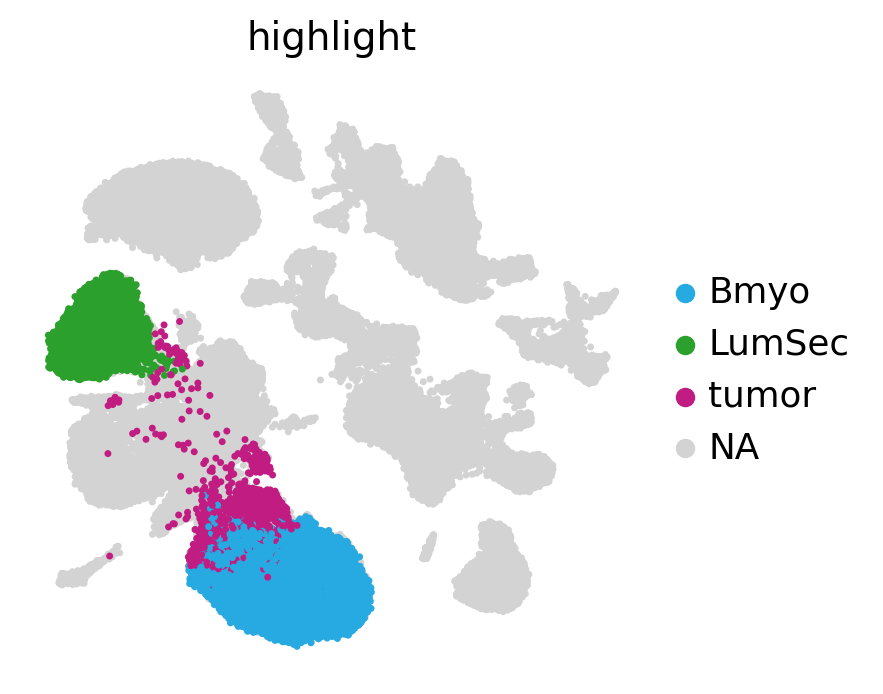

In [35]:
adata.obs['highlight'] = no_facs.obs['cell_type']

sc.pl.umap(adata, color='highlight', size=25,
          palette = {'Bmyo':'#27AAE1','LumSec':'#2ca02c','tumor':'#C11C82'})

In [66]:
epi = adata[adata.obs['cell_type'].isin(['Bmyo','LumSec','tumor'])]
epi = epi[epi.obs['condition'].isin(['wildtype','tumor'])]
epi = epi[~epi.obs['mouse_id'].isin(['mutant_5_five_pooled','mutant_4_four_pooled',
                                'wildtype_5_five_pooled','wildtype_4_two_pooled'])]

In [67]:
substring = 'tumor'

epi.obs['celltype_or_tumor_id'] = np.where(~epi.obs['condition'].str.contains(substring, na=False),  # Condition (inverted: ~ means NOT)
                   epi.obs['cell_type'],                                    # Value if condition is True (use 'a')
                   epi.obs['mouse_id'])

epi.obs['celltype_or_tumor_subtype'] = (
    epi.obs["celltype_or_tumor_id"]
    .map(lambda x: {"tumor_1": "TNBC_M",
                    "tumor_2": "TNBC_M",
                    "tumor_3": "TNBC_M",
                    "tumor_4": "TNBC_other",
                   "tumor_5": "TNBC_M",
                   "tumor_6": "TNBC_other",
                   "tumor_7": "TNBC_M"}.get(x, x))
    .astype("category")
)

epi.obs['celltype_or_tumor_id'].value_counts()

/tmp/ipykernel_2290317/4045435029.py:3: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  epi.obs['celltype_or_tumor_id'] = np.where(~epi.obs['condition'].str.contains(substring, na=False),  # Condition (inverted: ~ means NOT)


celltype_or_tumor_id
Bmyo                   5950
tumor_4_8mm_599        4356
tumor_5_25mm_111121    2365
tumor_3_2mm_633        2250
LumSec                 1906
tumor_6_25mm_081720    1782
tumor_2_1mm_966         594
tumor_1_1mm_654         554
tumor_7_25mm_120519     517
tumor                   114
Name: count, dtype: int64

/opt/apps/python/3.10.2/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:907: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(


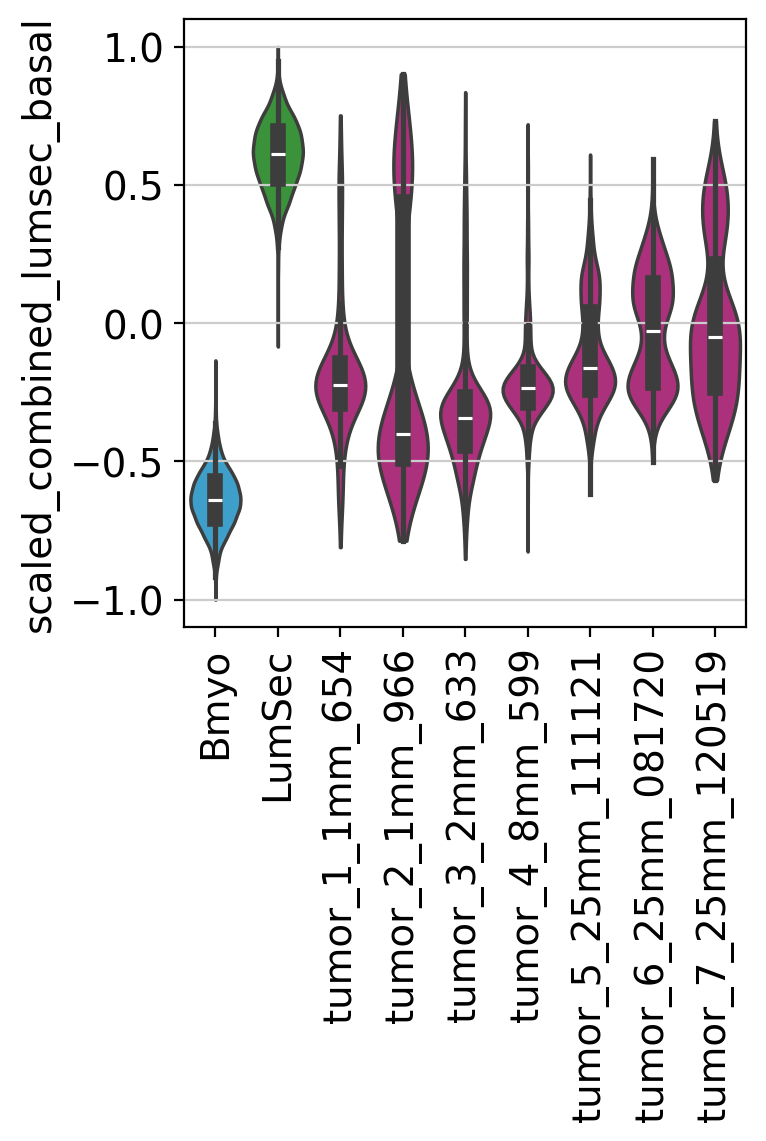

In [68]:
sc.pl.violin(epi, ["scaled_combined_lumsec_basal"], groupby="celltype_or_tumor_id", 
             rotation=90, order=['Bmyo', 'LumSec', 'tumor_1_1mm_654','tumor_2_1mm_966','tumor_3_2mm_633','tumor_4_8mm_599','tumor_5_25mm_111121','tumor_6_25mm_081720','tumor_7_25mm_120519'], 
             stripplot=False,
             inner='box', palette=['#27AAE1','#2ca02c','#C11C82','#C11C82','#C11C82','#C11C82','#C11C82','#C11C82','#C11C82']
            )#,save='_celltype_or_tumor_id_scaled_combined_lumsec_basal.pdf')

# mutant and wildtype epithelial only

In [75]:
work_dir = '/share/crsp/lab/dalawson/tzhuravl/CellPlex_Tumors/Scanpy_Seurat/scVI_epithelial/mutant_epi'

adata = pickle.load(open(os.path.join(work_dir, 'no_schwann_mut_wt_epi_no_LumHR_scvi.pkl'), 'rb'))

In [76]:
adata.obs=sub.obs.copy()

In [77]:
no_facs = adata[~adata.obs['mouse_id'].isin(['mutant_5_five_pooled','mutant_4_four_pooled',
                                'wildtype_5_five_pooled','wildtype_4_two_pooled'])]

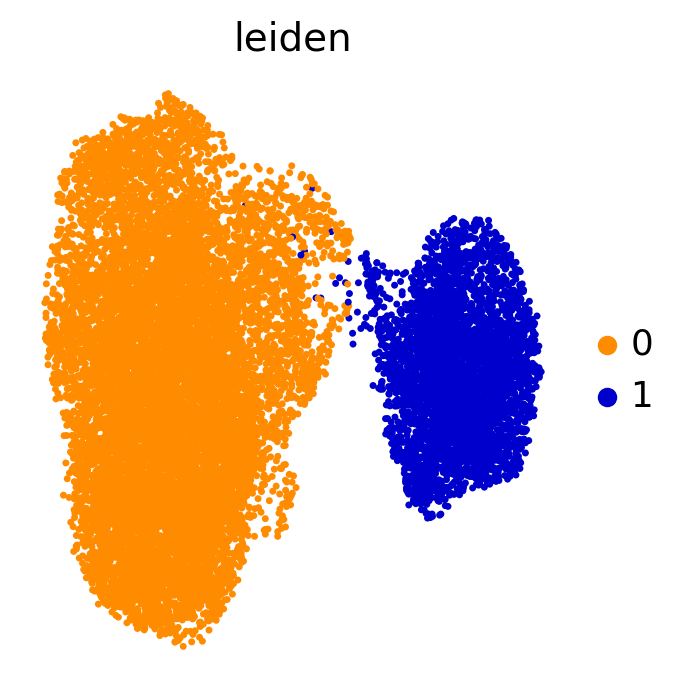

In [119]:
sc.tl.leiden(
    no_facs,
    resolution=0.1,
    random_state=0,
    n_iterations=2,
    directed=False,
)

sc.pl.umap(
    no_facs,
    color=["leiden"],s=25,palette=['darkorange','mediumblue'])

In [78]:
no_facs.obs['cell_type'] = (
    no_facs.obs["cell_type"]
    .map(lambda x: {"tumor": "tumor-like"}.get(x, x))
    .astype("category")
)

/tmp/ipykernel_2290317/2985116656.py:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  no_facs.obs['cell_type'] = (


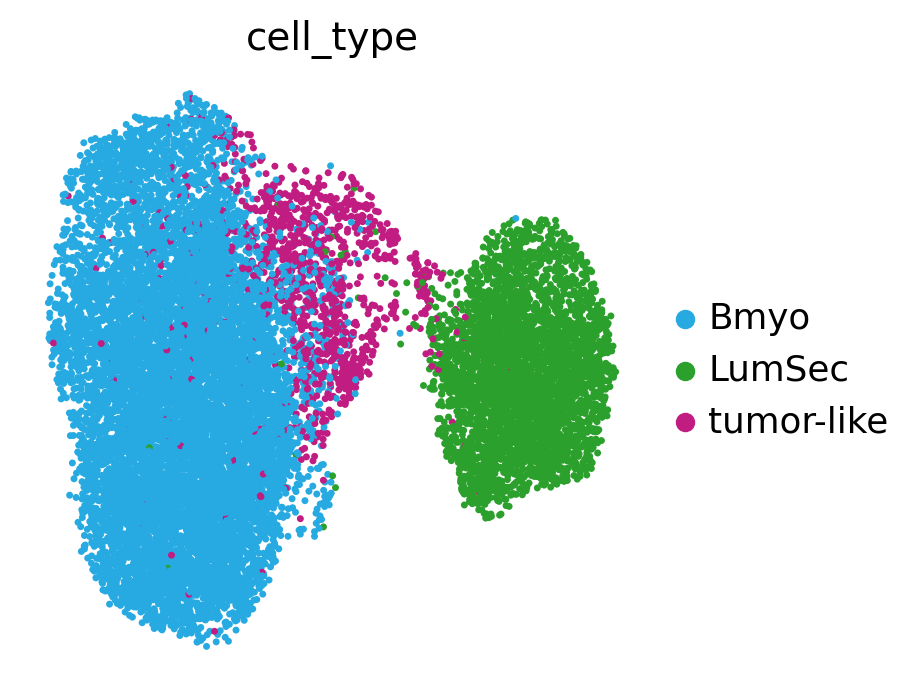

In [79]:
sc.pl.umap(no_facs, color='cell_type', size=25,
          palette = {'Bmyo':'#27AAE1','LumSec':'#2ca02c','tumor-like':'#C11C82'})

In [122]:
not_mutant_cnv=no_facs[~no_facs.obs['ploidy'].isin(['aneuploid'])]
not_mutant_cnv


not_mutant_cnv.obs['cnv_or_cell_type']=not_mutant_cnv.obs['cell_type']

no_facs.obs['cnv_or_cell_type']=not_mutant_cnv.obs['cnv_or_cell_type']

categories = np.array(
     ['Bmyo', 'LumSec', 'tumor-like', 'Aneuploid'])

no_facs.obs['cnv_or_cell_type'] = pd.Categorical(
   no_facs.obs['cnv_or_cell_type'], categories=categories, ordered=True)

no_facs.obs['cnv_or_cell_type'].fillna("Aneuploid", inplace=True,)

/tmp/ipykernel_2290317/1936558026.py:5: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  not_mutant_cnv.obs['cnv_or_cell_type']=not_mutant_cnv.obs['cell_type']
/tmp/ipykernel_2290317/1936558026.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  no_facs.obs['cnv_or_cell_type'].fillna("Aneuploid", inplace=True,)


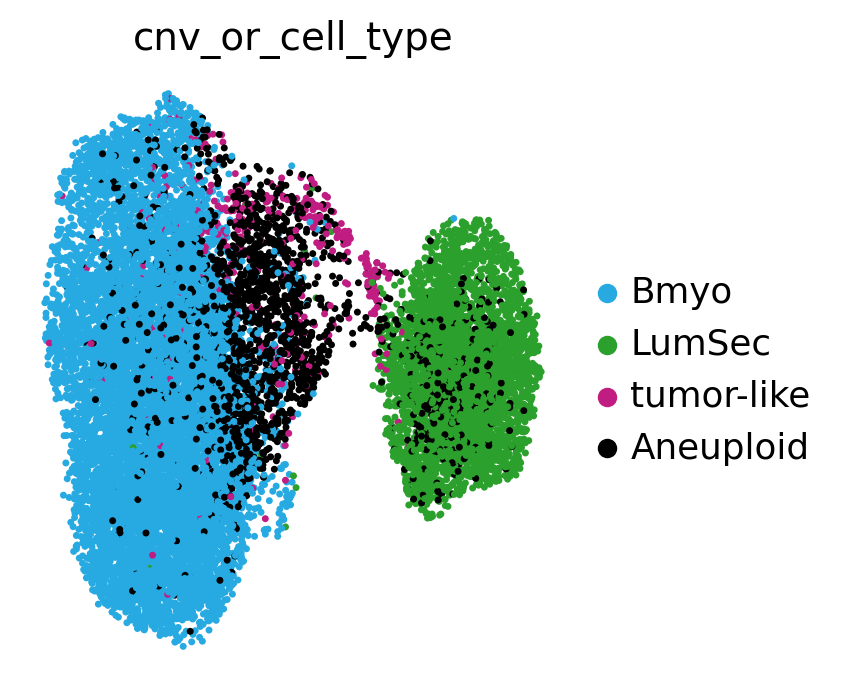

In [123]:
sc.pl.umap(no_facs, color='cnv_or_cell_type',size=25,
           palette=['#27AAE1','#2ca02c','#C11C82','black'])

In [124]:
no_facs.obs['condition'] = no_facs.obs["condition"].astype("str")
no_facs.obs['ploidy'] = no_facs.obs["ploidy"].astype("str")
no_facs.obs['cell_type'] = no_facs.obs["cell_type"].astype("str")

no_facs.obs['cell_type_condition'] = no_facs.obs['cell_type'] + ' ' + no_facs.obs['condition']
no_facs.obs['cell_type_ploidy'] = no_facs.obs['cell_type'] + ' ' + no_facs.obs['ploidy']


no_facs.obs['cell_type_condition'] = no_facs.obs["cell_type_condition"].astype("str")

no_facs.obs['cell_type_condition_ploidy'] = no_facs.obs['cell_type_condition'] + ' ' + no_facs.obs['ploidy']

In [125]:
no_facs.obs['cell_type_ploidy'].value_counts()

cell_type_ploidy
Bmyo diploid              10287
LumSec diploid             3531
tumor-like aneuploid        731
Bmyo aneuploid              724
tumor-like diploid          356
LumSec aneuploid            278
tumor-like not.defined        1
Name: count, dtype: int64

In [126]:
no_facs.obs['cell_type_ploidy'] = (
    no_facs.obs["cell_type_ploidy"]
    .map(lambda x: {"tumor-like not.defined":"tumor-like diploid"}.get(x, x))
    .astype("category")
)

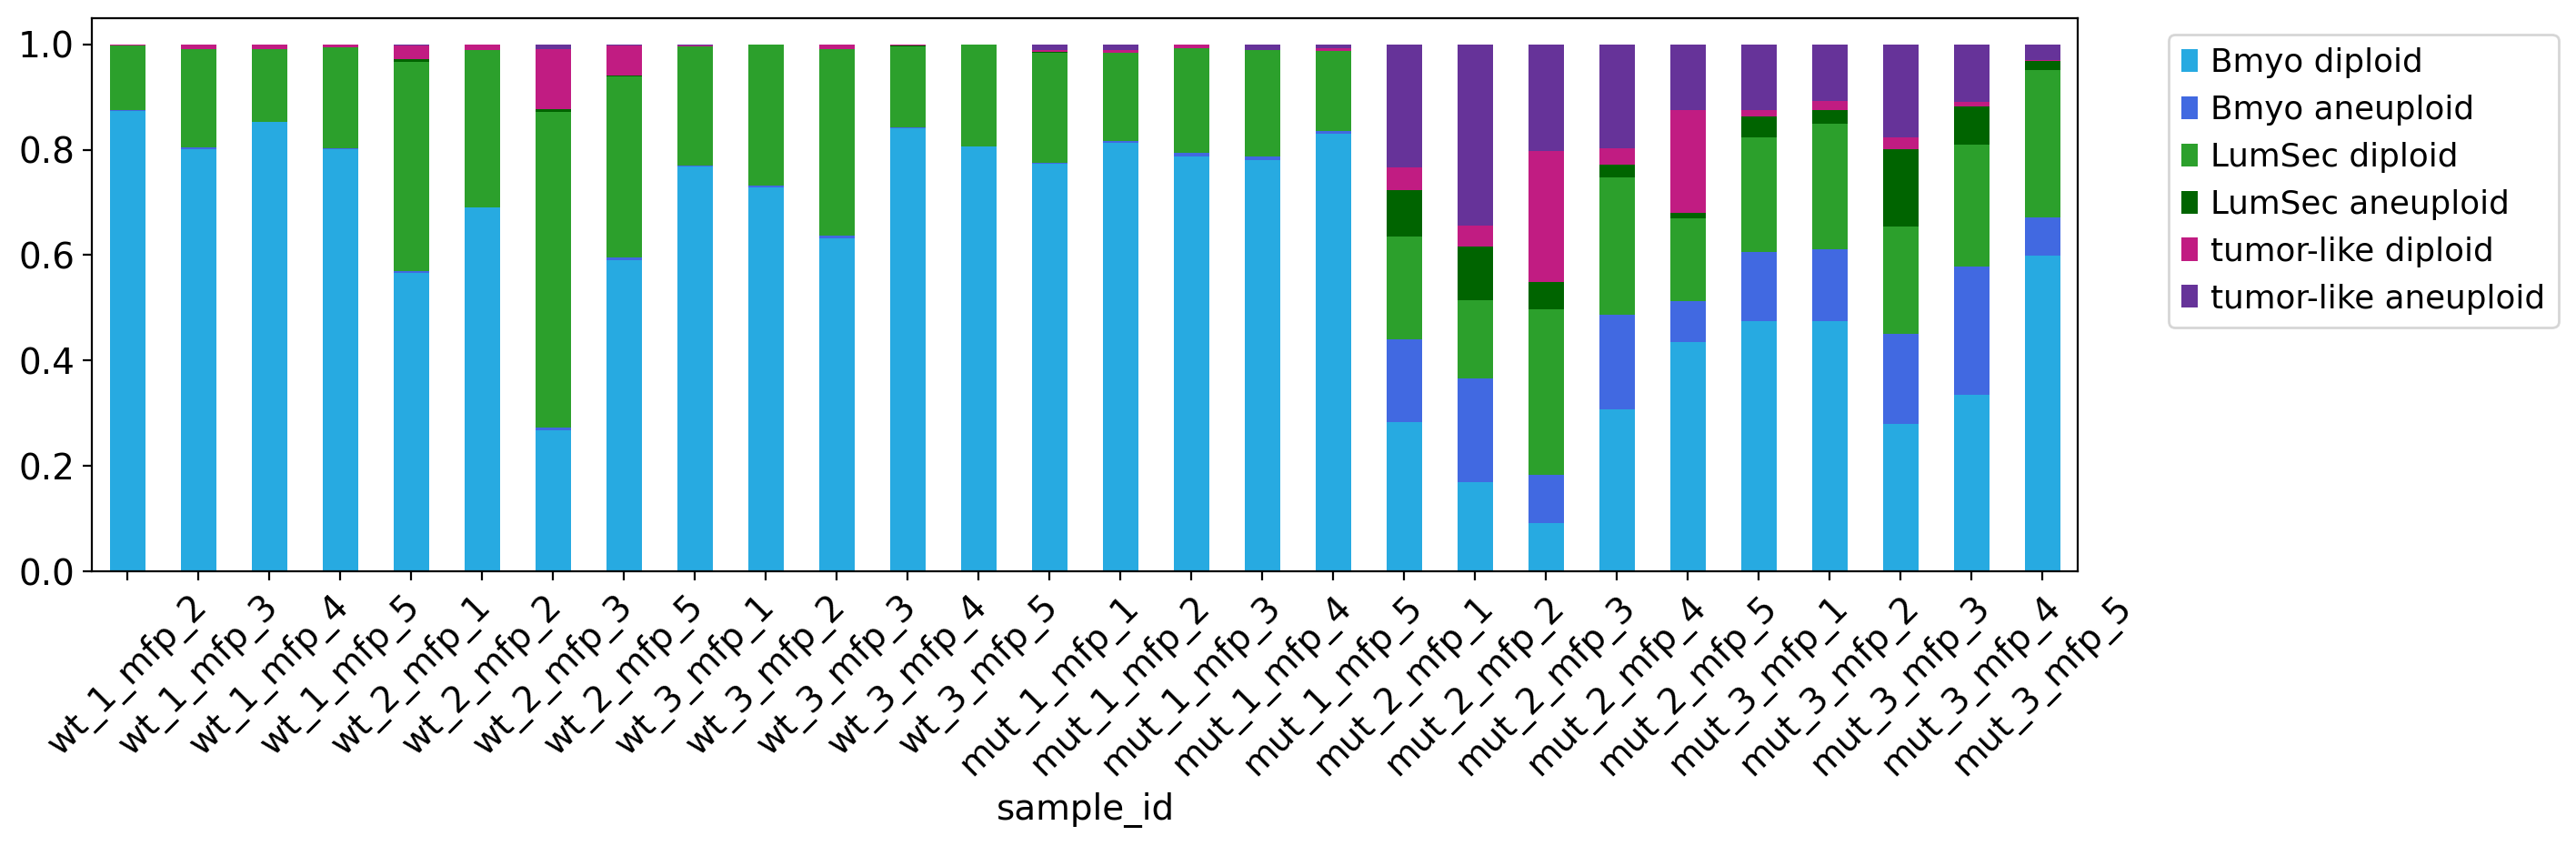

In [104]:
tmp = pd.crosstab(no_facs.obs['cell_type_ploidy'],no_facs.obs['sample_id'], 
                  normalize='columns').reindex(['Bmyo diploid','Bmyo aneuploid',
                                        'LumSec diploid','LumSec aneuploid',
                                        'tumor-like diploid','tumor-like aneuploid'])[["wt_1_mfp_2","wt_1_mfp_3","wt_1_mfp_4","wt_1_mfp_5",
    "wt_2_mfp_1","wt_2_mfp_2","wt_2_mfp_3","wt_2_mfp_5",
    "wt_3_mfp_1","wt_3_mfp_2","wt_3_mfp_3","wt_3_mfp_4","wt_3_mfp_5",
    "mut_1_mfp_1","mut_1_mfp_2","mut_1_mfp_3","mut_1_mfp_4","mut_1_mfp_5",
    "mut_2_mfp_1","mut_2_mfp_2","mut_2_mfp_3","mut_2_mfp_4","mut_2_mfp_5", 
    "mut_3_mfp_1","mut_3_mfp_2","mut_3_mfp_3","mut_3_mfp_4","mut_3_mfp_5"]].T.plot(kind='bar',
                                                                                             figsize=(14,4), 
                                                                                             stacked=True,
                                                                                             color=['#27AAE1','royalblue',
                                                               '#2ca02c','darkgreen',
                                                               '#C11C82','rebeccapurple'])
tmp.legend(title='', bbox_to_anchor=(1.25, 1),loc='upper right')
plt.grid(None)
pl.xticks(rotation=45)
pl.savefig('fig3_sample_id_cell_type_ploidy_stacked.pdf', bbox_inches='tight')

In [111]:
colors=['#8fb0ff', '#997d87', '#5a0007', '#809693', '#6a3a4c', '#1b4400', '#4fc601', '#3b5dff', '#4a3b53', '#ff2f80', '#61615a', '#ba0900', '#6b7900', '#00c2a0', '#ffaa92', '#2b0f1b','#ffff00','#ff34ff', '#ff4a46', '#008941', '#006fa6', '#a30059', '#ffdbe5', '#7a4900', '#0000a6', '#63ffac', '#b79762', '#004d43']

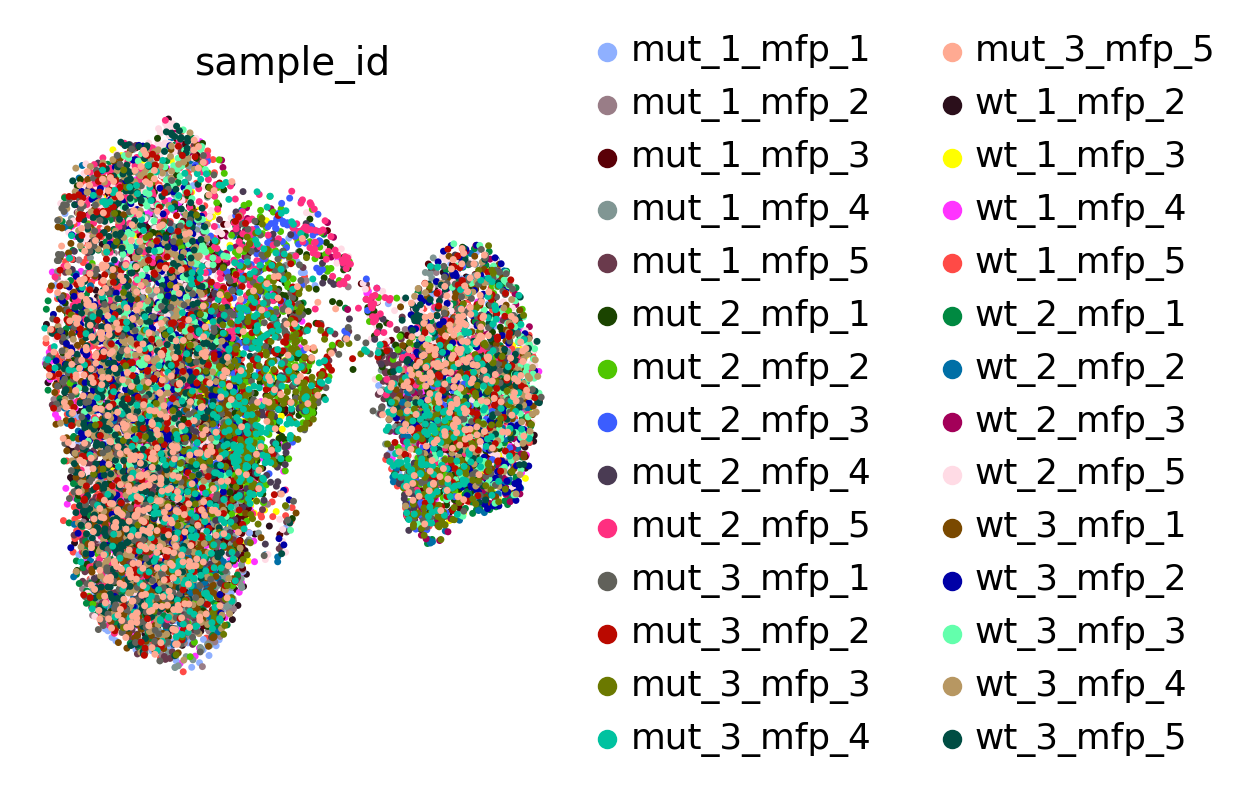

In [113]:
pl.rcParams["figure.figsize"] = (3.5,4)

sc.pl.umap(no_facs, color='sample_id',palette=colors,s=25,save='_sample_id.pdf')

In [127]:
no_facs.obs['cell_type_condition_ploidy'] = (
    no_facs.obs["cell_type_condition_ploidy"]
    .map(lambda x: {"tumor-like mutant not.defined":"tumor-like mutant diploid"}.get(x, x))
    .astype("category")
)

In [128]:
category_order = ['Bmyo wildtype', 'Bmyo mutant',
                 'LumSec wildtype', 'LumSec mutant',
                 'tumor-like wildtype', 'tumor-like mutant']

no_facs.obs['cell_type_condition'] = pd.Categorical(
   no_facs.obs['cell_type_condition'], categories=category_order, ordered=True)

In [46]:
df=no_facs.obs
df['Match_aneu'] = (df['ploidy'] == "aneuploid").astype(int)
category_match = df.groupby('cell_type_condition')['Match_aneu'].mean() * 100
rep_match = df.groupby(['cell_type_condition','orig_ident'])['Match_aneu'].mean() * 100
rep_match=pd.DataFrame(rep_match)

/tmp/ipykernel_2290317/3604800386.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  category_match = df.groupby('cell_type_condition')['Match_aneu'].mean() * 100
/tmp/ipykernel_2290317/3604800386.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rep_match = df.groupby(['cell_type_condition','orig_ident'])['Match_aneu'].mean() * 100


/tmp/ipykernel_2290317/1905627985.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='cell_type_condition', y='Match_aneu', data=rep_match, palette=colors, order=category_order)


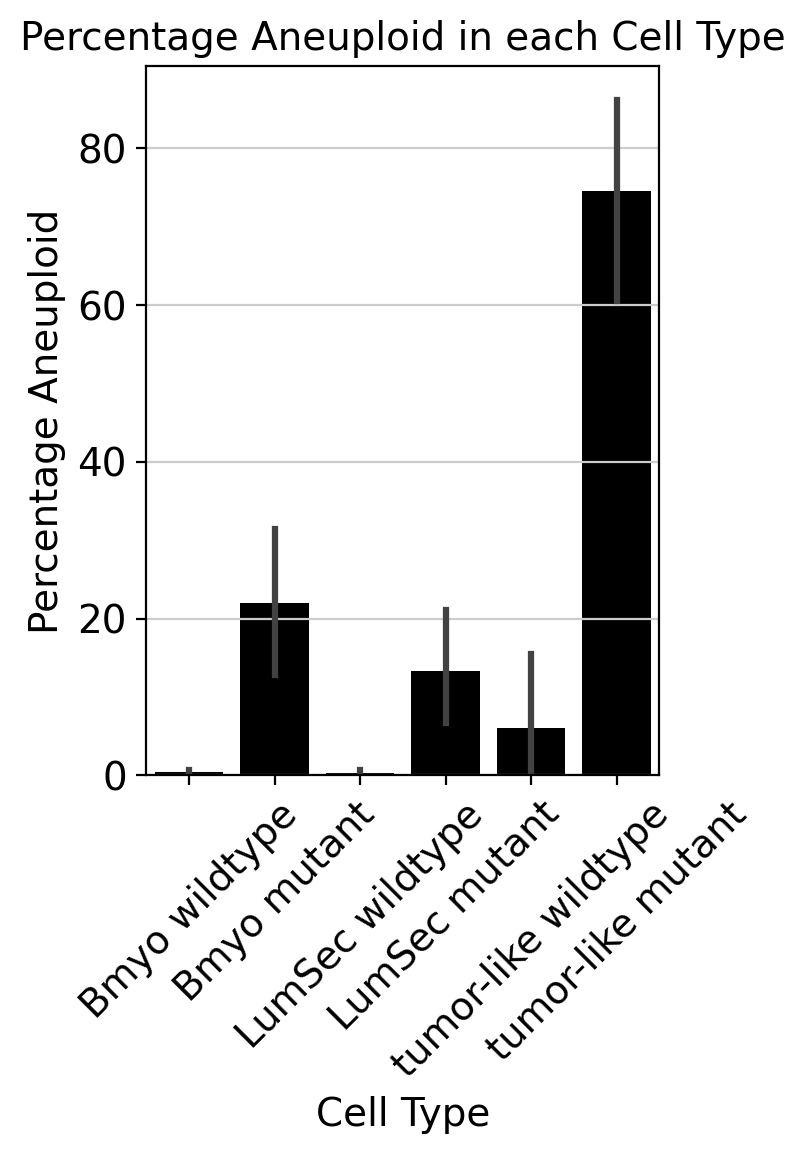

In [47]:
colors=['black','black','black','black','black','black']

category_order = ['Bmyo wildtype', 'Bmyo mutant',
                 'LumSec wildtype', 'LumSec mutant',
                 'tumor-like wildtype', 'tumor-like mutant']

plt.figure(figsize=(4, 6))
sns.barplot(x='cell_type_condition', y='Match_aneu', data=rep_match, palette=colors, order=category_order)
plt.xlabel('Cell Type')
#plt.ylim(0, 100)
plt.tick_params(axis='x', labelrotation=45)
plt.ylabel('Percentage Aneuploid')
plt.title('Percentage Aneuploid in each Cell Type')
plt.tight_layout()
#plt.savefig('percent_aneuploid_per_celltype_condition.pdf', format='pdf')
plt.show()

In [129]:
no_facs.obs['Figure_3_id'] = (
    no_facs.obs["cell_type_condition_ploidy"]
    .map(lambda x: {"Bmyo wildtype diploid": "Bmyo WT",
                    "Bmyo mutant diploid": "Bmyo mutant diploid",
                    "LumSec wildtype diploid": "LumSec WT",
                    "LumSec mutant diploid": "LumSec mutant diploid",
                   "tumor-like mutant aneuploid": "tumor-like mutant aneuploid",
                   "Bmyo mutant aneuploid": "Bmyo mutant aneuploid",
                    "LumSec mutant aneuploid": "LumSec mutant aneuploid",
                    "tumor mutant diploid": "tumor-like mutant diploid",
                    "tumor-like wildtype diploid": "tumor-like WT",
                    "Bmyo wildtype aneuploid": "Bmyo WT",
                   "LumSec wildtype aneuploid": "LumSec WT",
                   "tumor-like wildtype aneuploid": "tumor-like WT"}.get(x, x))
    .astype("category")
)

no_facs.obs['Figure_3_id'].value_counts()

Figure_3_id
Bmyo WT                        5950
Bmyo mutant diploid            4354
LumSec WT                      1906
LumSec mutant diploid          1632
tumor-like mutant aneuploid     726
Bmyo mutant aneuploid           707
LumSec mutant aneuploid         271
tumor-like mutant diploid       248
tumor-like WT                   114
Name: count, dtype: int64

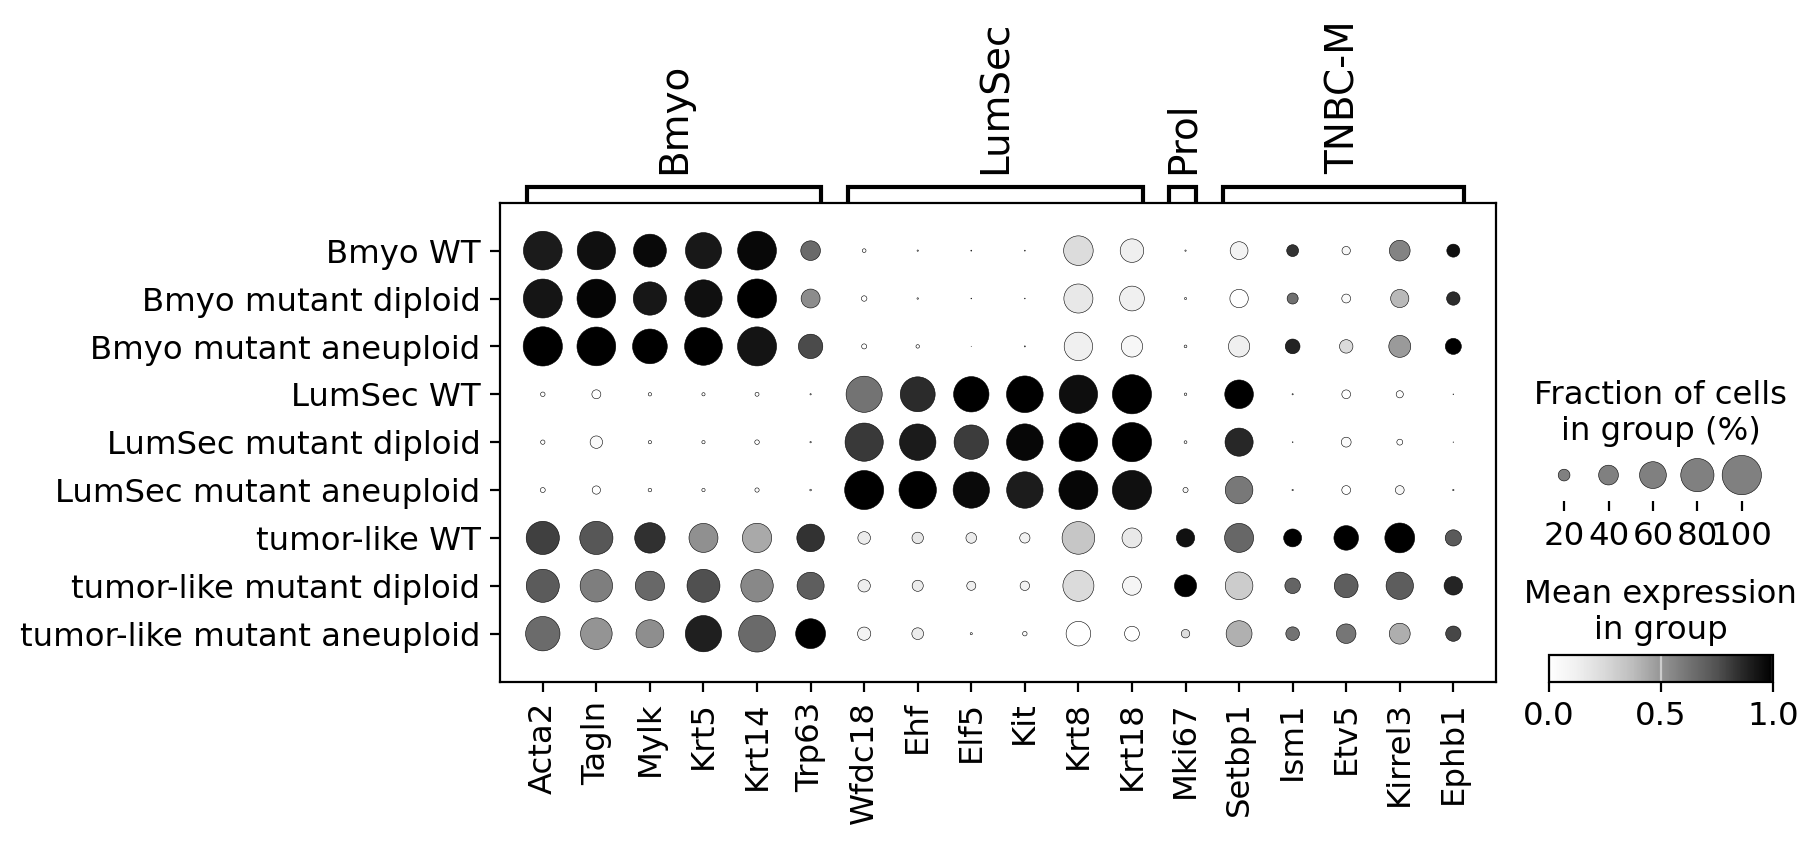

In [49]:
marker_genes = {
    "Bmyo": ["Acta2","Tagln","Mylk","Krt5","Krt14","Trp63"],
    "LumSec": ["Wfdc18","Ehf","Elf5","Kit","Krt8","Krt18"],
    "Prol": ["Mki67"],
    "TNBC-M":["Setbp1","Ism1","Etv5","Kirrel3","Ephb1"]}


sc.pl.dotplot(no_facs, marker_genes, groupby="Figure_3_id",
              standard_scale="var",swap_axes=False,cmap="Grays",
             categories_order=['Bmyo WT',
                  'Bmyo mutant diploid',
                  'Bmyo mutant aneuploid',
                 'LumSec WT',
                  'LumSec mutant diploid',
                  'LumSec mutant aneuploid',
                 'tumor-like WT',
                  'tumor-like mutant diploid',
                 'tumor-like mutant aneuploid'],
              #save='_Fig3_canonical_cell_type_condition_ploidy.pdf'
             )

/opt/apps/python/3.10.2/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:907: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(


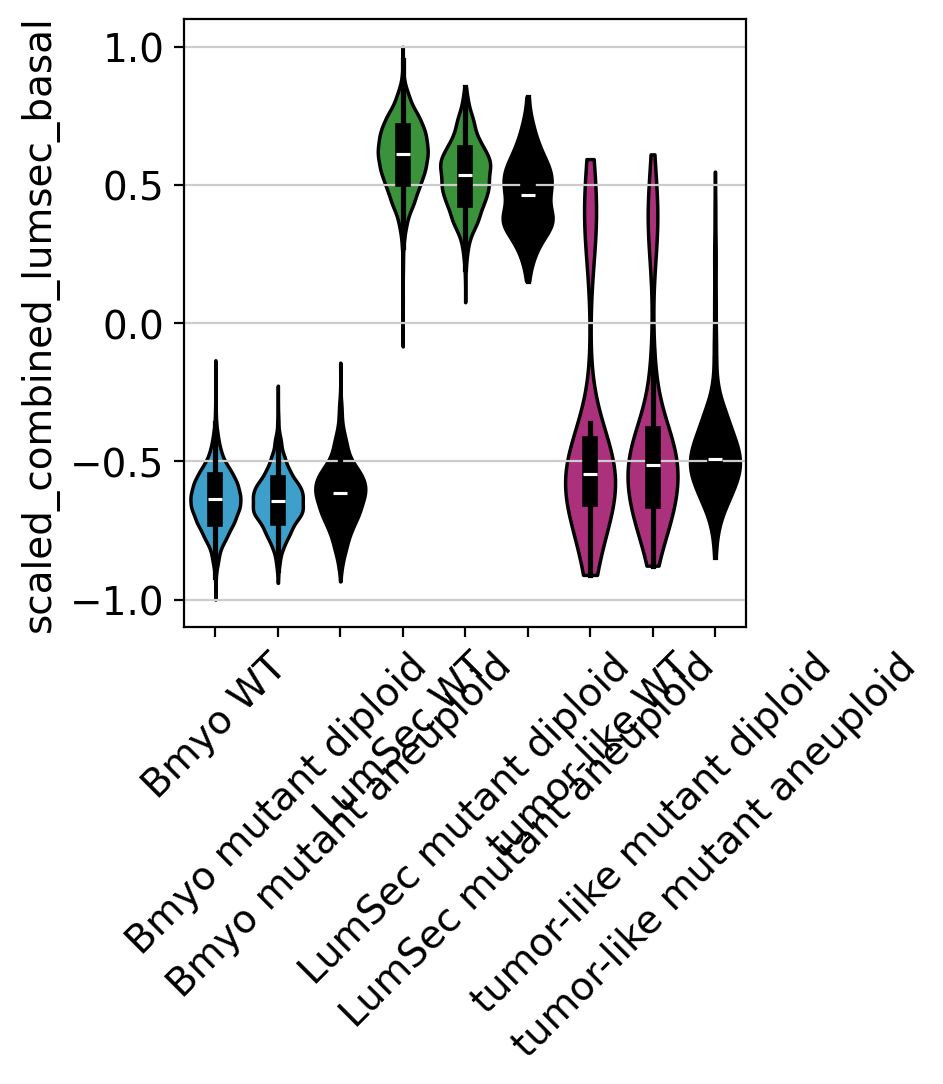

In [50]:
#pl.rcParams["figure.figsize"] = (4.75,5)

sc.pl.violin(no_facs, ["scaled_combined_lumsec_basal"], groupby="Figure_3_id", 
             rotation=45, palette = ['#27AAE1','#27AAE1','black',
                                     '#2ca02c','#2ca02c','black',
                                     '#C11C82','#C11C82','black'],
             stripplot=False,order=['Bmyo WT',
                  'Bmyo mutant diploid',
                  'Bmyo mutant aneuploid',
                 'LumSec WT',
                  'LumSec mutant diploid',
                  'LumSec mutant aneuploid',
                 'tumor-like WT',
                  'tumor-like mutant diploid',
                 'tumor-like mutant aneuploid'],
             inner='box',
             #save='_fig3_violin_scaled_scores_cell_type_ploidy.pdf'
            )

In [51]:
no_facs.obs['sc_TNBC_subtype'].value_counts()

sc_TNBC_subtype
M      14947
BL1      573
BL2      373
LAR       12
UNS        1
Name: count, dtype: int64

In [52]:
sub=no_facs[no_facs.obs['sc_TNBC_subtype'].isin(['BL1','BL2','LAR','M'])]

/opt/apps/python/3.10.2/lib/python3.10/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list


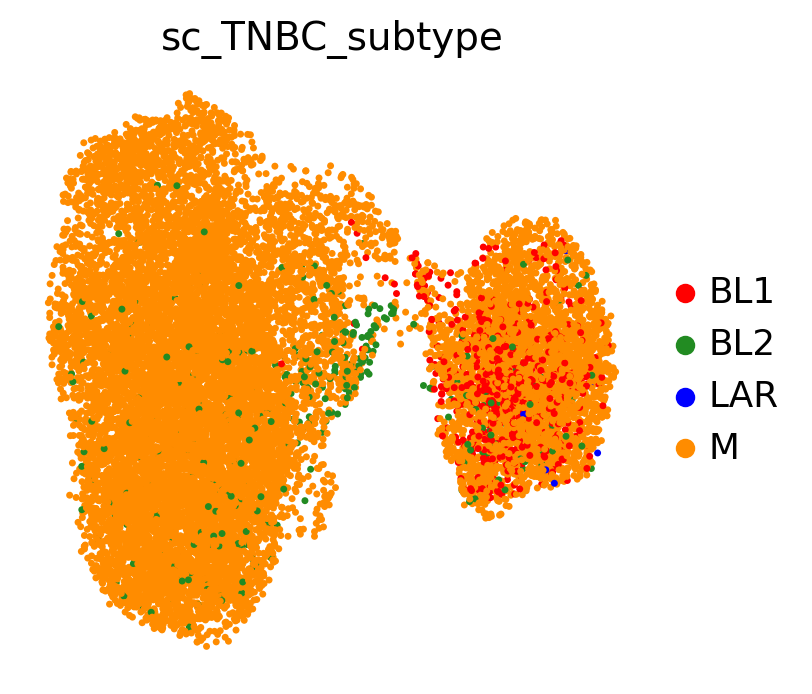

In [53]:
sc.pl.umap(sub, color='sc_TNBC_subtype', size=25,
          palette = {'BL1':'red',
                                                'BL2':'forestgreen',
                                                'LAR':'blue',
                                               'M':'darkorange',
                                               'UNS':'grey'}
          )

(array([0, 1, 2, 3, 4, 5, 6, 7, 8]),
 [Text(0, 0, 'Bmyo WT'),
  Text(1, 0, 'Bmyo mutant diploid'),
  Text(2, 0, 'Bmyo mutant aneuploid'),
  Text(3, 0, 'LumSec WT'),
  Text(4, 0, 'LumSec mutant diploid'),
  Text(5, 0, 'LumSec mutant aneuploid'),
  Text(6, 0, 'tumor-like WT'),
  Text(7, 0, 'tumor-like mutant diploid'),
  Text(8, 0, 'tumor-like mutant aneuploid')])

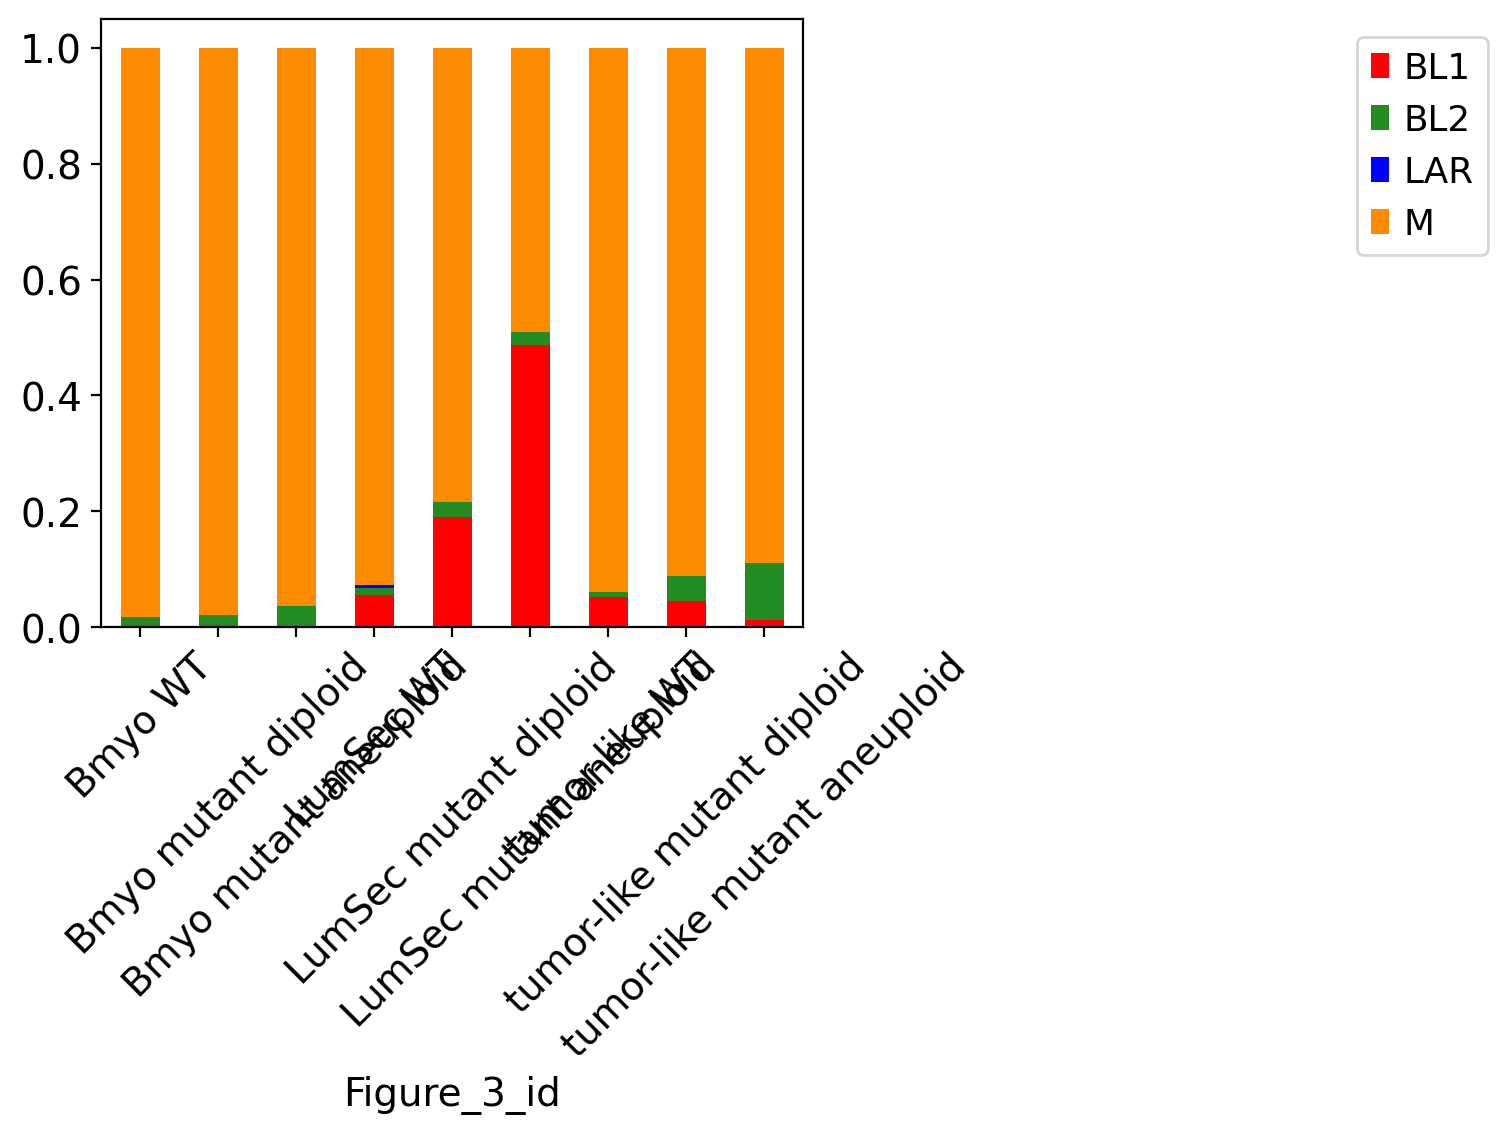

In [54]:
tmp = pd.crosstab(sub.obs['sc_TNBC_subtype'],sub.obs['Figure_3_id'], 
                  normalize='columns').reindex()[['Bmyo WT',
                  'Bmyo mutant diploid',
                  'Bmyo mutant aneuploid',
                 'LumSec WT',
                  'LumSec mutant diploid',
                  'LumSec mutant aneuploid',
                 'tumor-like WT',
                  'tumor-like mutant diploid',
                 'tumor-like mutant aneuploid']].T.plot(kind='bar',figsize=(4.5,4), stacked=True,
                                                                                                                  color=['red',
                                                'forestgreen',
                                                'blue',
                                               'darkorange',
                                               'grey'])
tmp.legend(title='', bbox_to_anchor=(2, 1),loc='upper right')
plt.grid(None)
pl.xticks(rotation=45)
#pl.savefig('fig3_subtype_cell_type_ploidy_stacked.pdf', bbox_inches='tight')

In [55]:
sub=no_facs[no_facs.obs['sc_TNBC_subtype'].isin(['BL1','BL2','LAR','M'])]
sub=sub[sub.obs['condition'].isin(['wildtype'])]

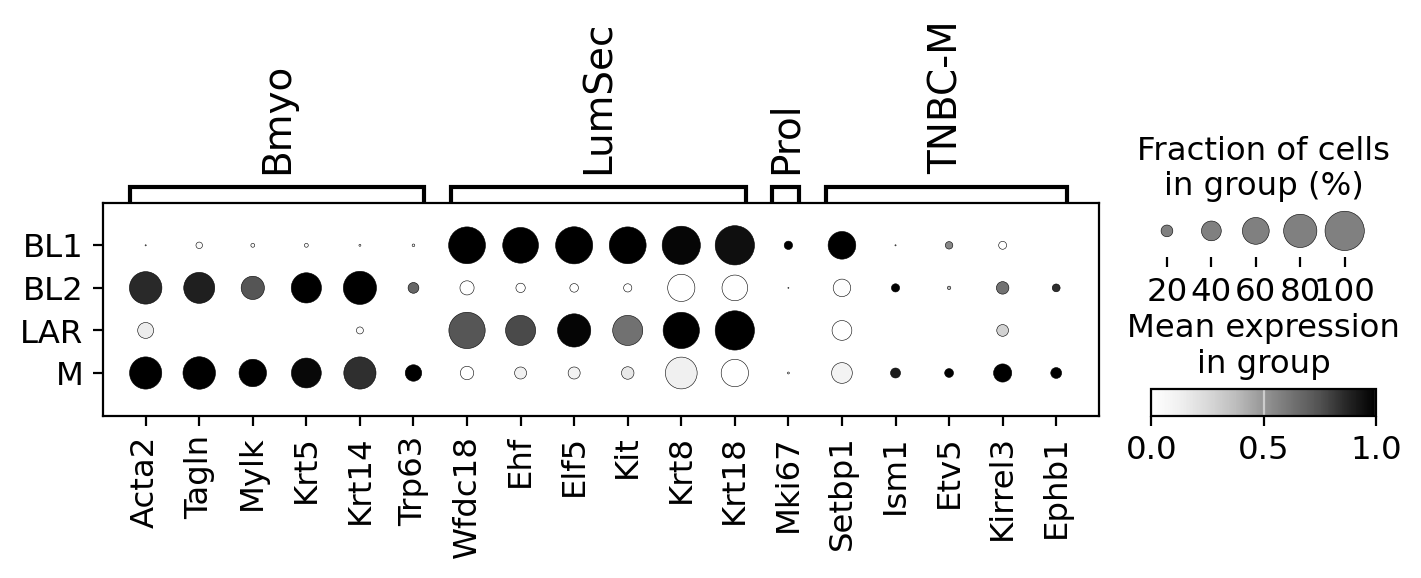

In [56]:
marker_genes = {
    "Bmyo": ["Acta2","Tagln","Mylk","Krt5","Krt14","Trp63"],
    "LumSec": ["Wfdc18","Ehf","Elf5","Kit","Krt8","Krt18"],
    "Prol": ["Mki67"],
    "TNBC-M":["Setbp1","Ism1","Etv5","Kirrel3","Ephb1"]}


sc.pl.dotplot(sub, marker_genes, groupby="sc_TNBC_subtype",
              standard_scale="var",swap_axes=False,cmap="Grays",
              save='_Fig3_canonical_subtype_wt.pdf'
             )

In [57]:
sub=no_facs[no_facs.obs['sc_TNBC_subtype'].isin(['BL1','BL2','LAR','M'])]
sub=sub[sub.obs['condition'].isin(['mutant'])]

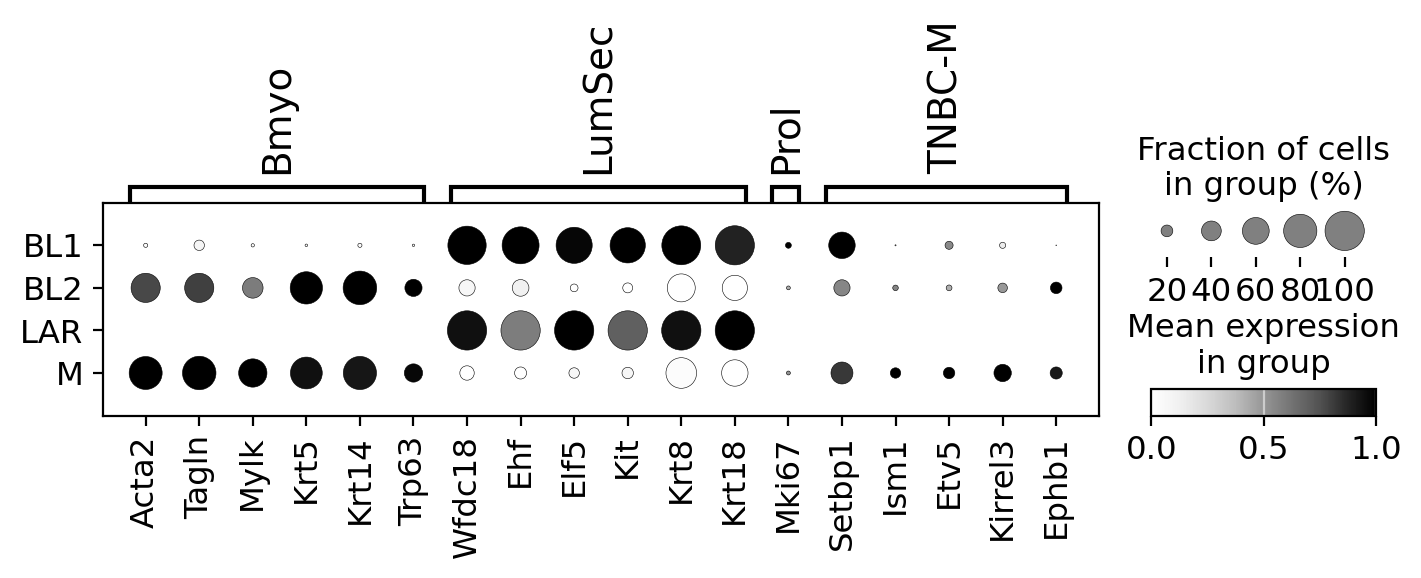

In [58]:
marker_genes = {
    "Bmyo": ["Acta2","Tagln","Mylk","Krt5","Krt14","Trp63"],
    "LumSec": ["Wfdc18","Ehf","Elf5","Kit","Krt8","Krt18"],
    "Prol": ["Mki67"],
    "TNBC-M":["Setbp1","Ism1","Etv5","Kirrel3","Ephb1"]}


sc.pl.dotplot(sub, marker_genes, groupby="sc_TNBC_subtype",
              standard_scale="var",swap_axes=False,cmap="Grays",
              save='_Fig3_canonical_subtype_mut.pdf'
             )

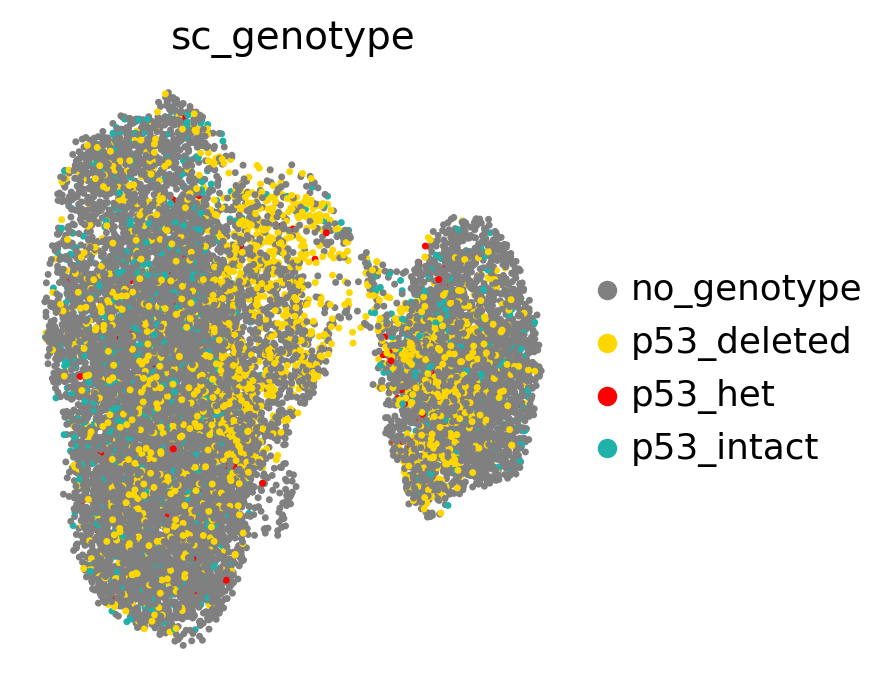

In [120]:
sc.pl.umap(no_facs, color='sc_genotype', size=25,
           palette=["grey","gold","red","lightseagreen"]
          )

(array([0, 1, 2, 3, 4, 5, 6, 7, 8]),
 [Text(0, 0, 'Bmyo WT'),
  Text(1, 0, 'Bmyo mutant diploid'),
  Text(2, 0, 'Bmyo mutant aneuploid'),
  Text(3, 0, 'LumSec WT'),
  Text(4, 0, 'LumSec mutant diploid'),
  Text(5, 0, 'LumSec mutant aneuploid'),
  Text(6, 0, 'tumor-like WT'),
  Text(7, 0, 'tumor-like mutant diploid'),
  Text(8, 0, 'tumor-like mutant aneuploid')])

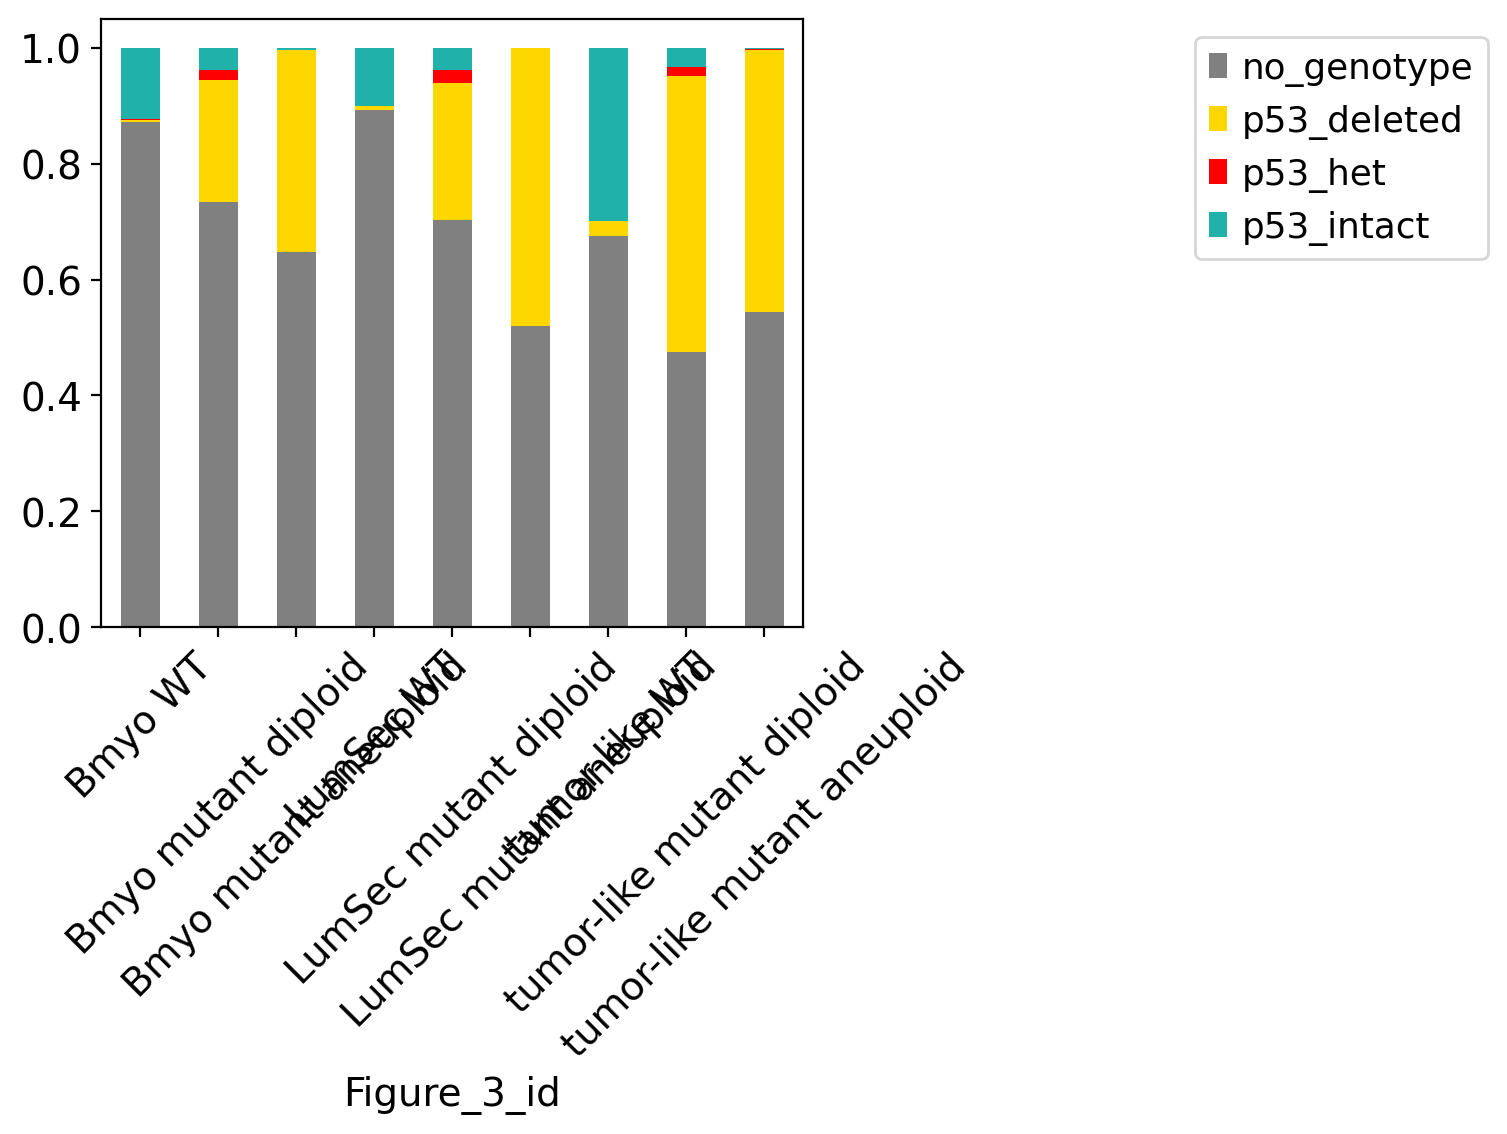

In [130]:
tmp = pd.crosstab(no_facs.obs['sc_genotype'],no_facs.obs['Figure_3_id'], 
                  normalize='columns').reindex()[['Bmyo WT',
                  'Bmyo mutant diploid',
                  'Bmyo mutant aneuploid',
                 'LumSec WT',
                  'LumSec mutant diploid',
                  'LumSec mutant aneuploid',
                 'tumor-like WT',
                  'tumor-like mutant diploid',
                 'tumor-like mutant aneuploid']].T.plot(kind='bar',figsize=(4.5,4), stacked=True,
                                                        color=["grey","gold","red","lightseagreen"])
tmp.legend(title='', bbox_to_anchor=(2, 1),loc='upper right')
plt.grid(None)
pl.xticks(rotation=45)
#pl.savefig('fig3_genotype_cell_type_ploidy_stacked.pdf', bbox_inches='tight')

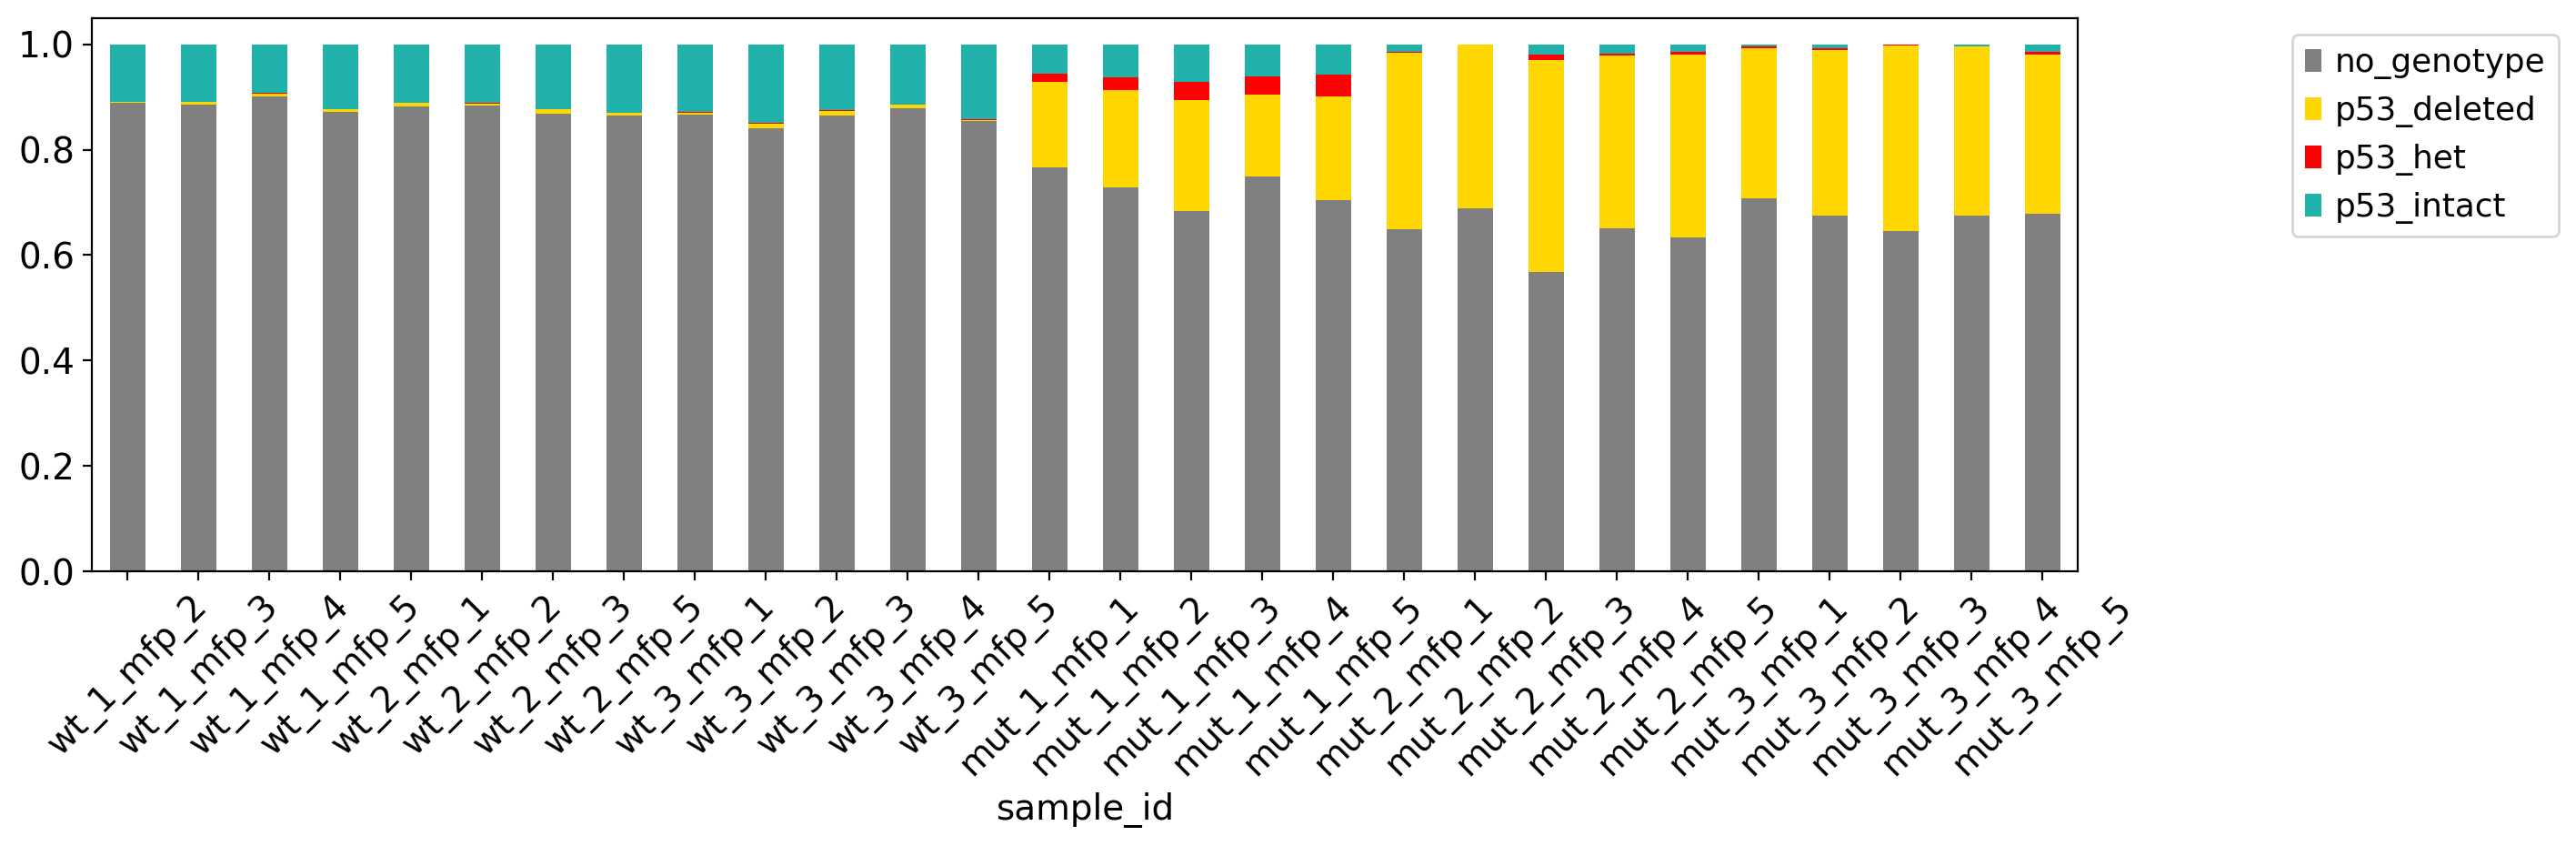

In [115]:
tmp = pd.crosstab(no_facs.obs['sc_genotype'],no_facs.obs['sample_id'], 
                  normalize='columns').reindex()[["wt_1_mfp_2","wt_1_mfp_3","wt_1_mfp_4","wt_1_mfp_5",
    "wt_2_mfp_1","wt_2_mfp_2","wt_2_mfp_3","wt_2_mfp_5",
    "wt_3_mfp_1","wt_3_mfp_2","wt_3_mfp_3","wt_3_mfp_4","wt_3_mfp_5",
    "mut_1_mfp_1","mut_1_mfp_2","mut_1_mfp_3","mut_1_mfp_4","mut_1_mfp_5",
    "mut_2_mfp_1","mut_2_mfp_2","mut_2_mfp_3","mut_2_mfp_4","mut_2_mfp_5", 
    "mut_3_mfp_1","mut_3_mfp_2","mut_3_mfp_3","mut_3_mfp_4","mut_3_mfp_5"]].T.plot(kind='bar',
                                                                                             figsize=(14,4), 
                                                                                             stacked=True,
                                                                                             color=["grey","gold","red","lightseagreen"])
tmp.legend(title='', bbox_to_anchor=(1.25, 1),loc='upper right')
plt.grid(None)
pl.xticks(rotation=45)
pl.savefig('fig3_sample_id_genotype_stacked.pdf', bbox_inches='tight')

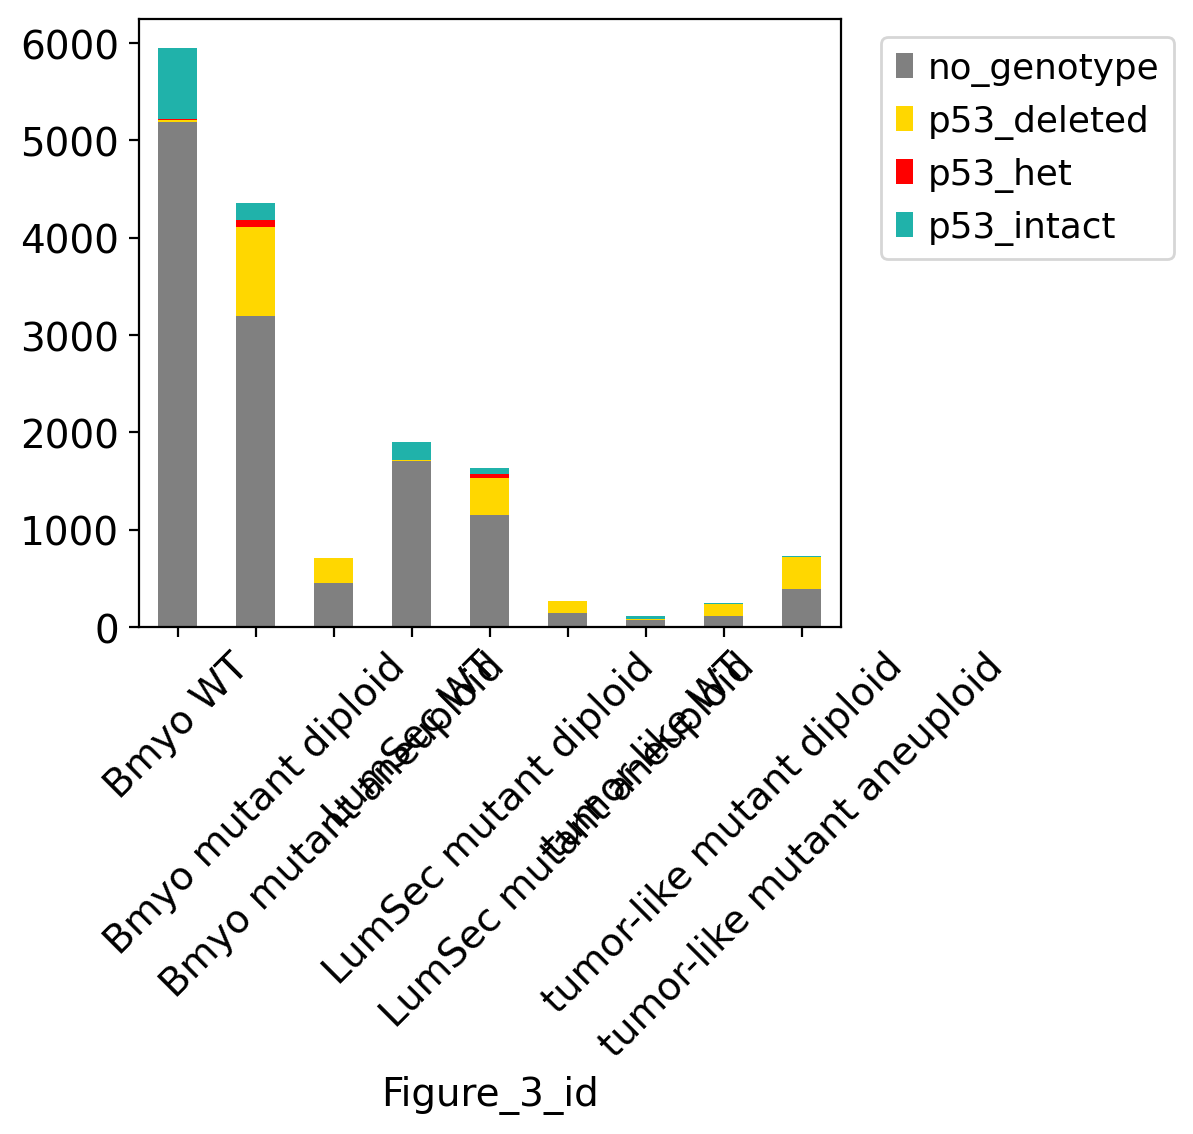

In [132]:
tmp = pd.crosstab(no_facs.obs['sc_genotype'],no_facs.obs['Figure_3_id']).reindex()[['Bmyo WT',
                  'Bmyo mutant diploid',
                  'Bmyo mutant aneuploid',
                 'LumSec WT',
                  'LumSec mutant diploid',
                  'LumSec mutant aneuploid',
                 'tumor-like WT',
                  'tumor-like mutant diploid',
                 'tumor-like mutant aneuploid']].T.plot(kind='bar',figsize=(4.5,4), stacked=True,
                                                        color=["grey","gold","red","lightseagreen"])
tmp.legend(title='', bbox_to_anchor=(1.5, 1),loc='upper right')
plt.grid(None)
pl.xticks(rotation=45)
pl.savefig('fig3_genotype_cell_type_ploidy_stacked.pdf', bbox_inches='tight')

In [61]:
sub=no_facs[~no_facs.obs['sc_genotype'].isin(['no_genotype'])]

/opt/apps/python/3.10.2/lib/python3.10/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list


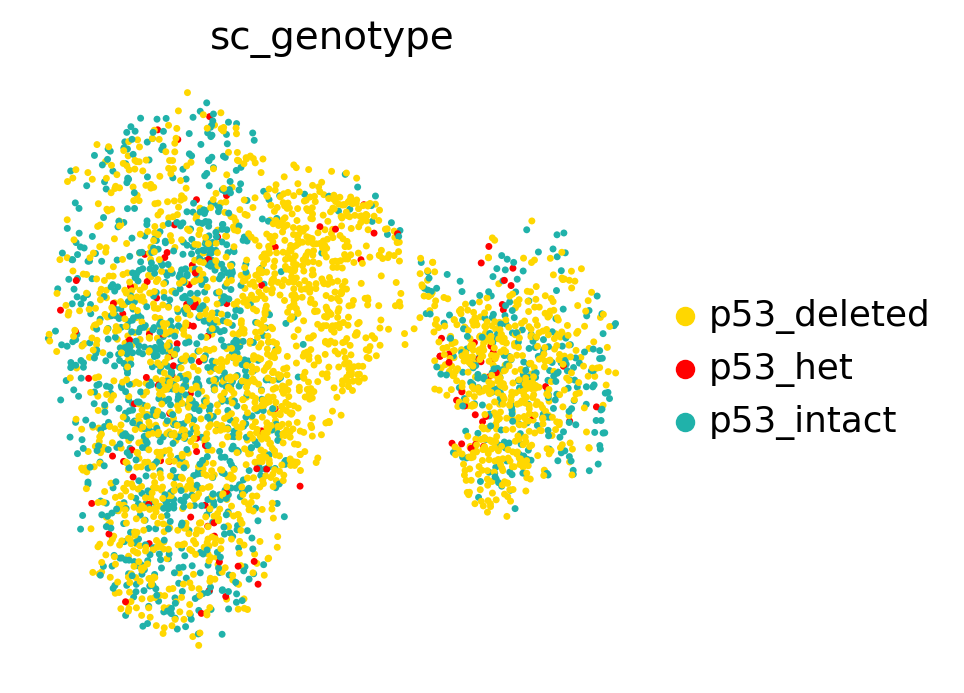

In [62]:
sc.pl.umap(sub, color='sc_genotype', size=25,
           palette=["gold","red","lightseagreen"],
           sort_order=None
          )

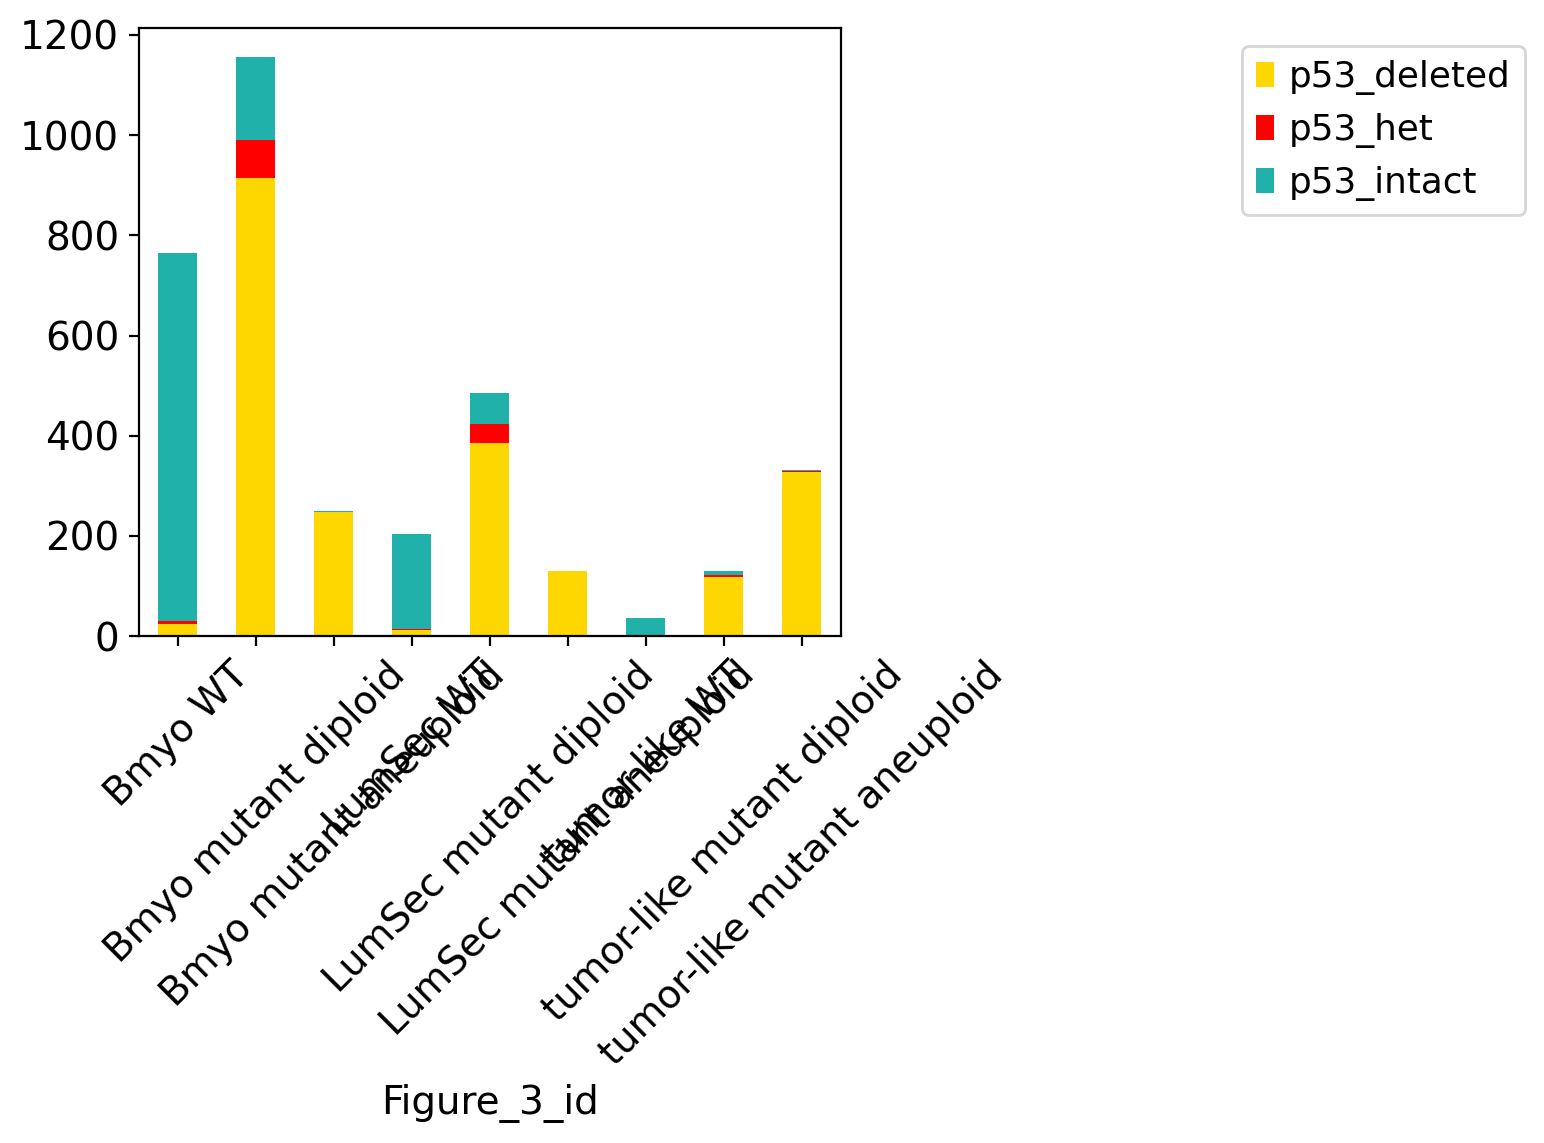

In [63]:
tmp = pd.crosstab(sub.obs['sc_genotype'],sub.obs['Figure_3_id']).reindex()[['Bmyo WT',
                  'Bmyo mutant diploid',
                  'Bmyo mutant aneuploid',
                 'LumSec WT',
                  'LumSec mutant diploid',
                  'LumSec mutant aneuploid',
                 'tumor-like WT',
                  'tumor-like mutant diploid',
                 'tumor-like mutant aneuploid']].T.plot(kind='bar',figsize=(4.5,4), stacked=True,
                                                        color=["gold","red","lightseagreen"])
tmp.legend(title='', bbox_to_anchor=(2, 1),loc='upper right')
plt.grid(None)
pl.xticks(rotation=45)
pl.savefig('fig3_genotype_cell_type_ploidy_stacked_raw.pdf', bbox_inches='tight')

<h1 id="Walid-Khaled-Bach-et-al">Walid Khaled Bach et al - all cells</h1>

In [139]:
adata = sc.read_h5ad('/share/crsp/lab/dalawson/share/Brca_mouse/WalidKhaled/all_cells_bigsur_merged.h5ad')

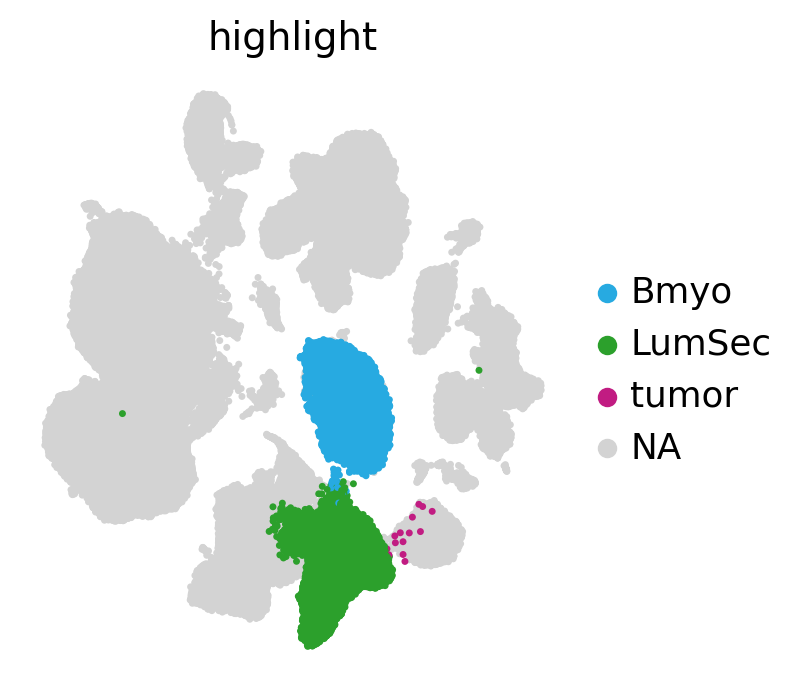

In [140]:
sub = adata[adata.obs['Group'].isin(['Control','WKBR_MG'])]
sub = sub[~sub.obs['SampleID'].isin(['CBLT','CBLA13'])]
sub = sub[sub.obs['cell_type'].isin(['Bmyo','LumSec','tumor'])]

adata.obs['highlight'] = sub.obs['cell_type']

sc.pl.umap(adata, color='highlight', size=25,
          palette = {'Bmyo':'#27AAE1','LumSec':'#2ca02c','tumor':'#C11C82'})

<h1>Walid Khaled Bach et al - epithelial subset</h1>

In [155]:
work_dir = '/share/crsp/lab/dalawson/share/Brca_mouse/WalidKhaled'

epi = pickle.load(open(os.path.join(work_dir, 'epithelial_mut_wt_LumHR_bigsur_scvi_from_all.pkl'), 'rb'))

In [156]:
epi = epi[~epi.obs['SampleID'].isin(['CBLT',
                                           'CBLA13'])]

/opt/apps/python/3.10.2/lib/python3.10/site-packages/scanpy/tools/_leiden.py:199: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs[key_added] = pd.Categorical(


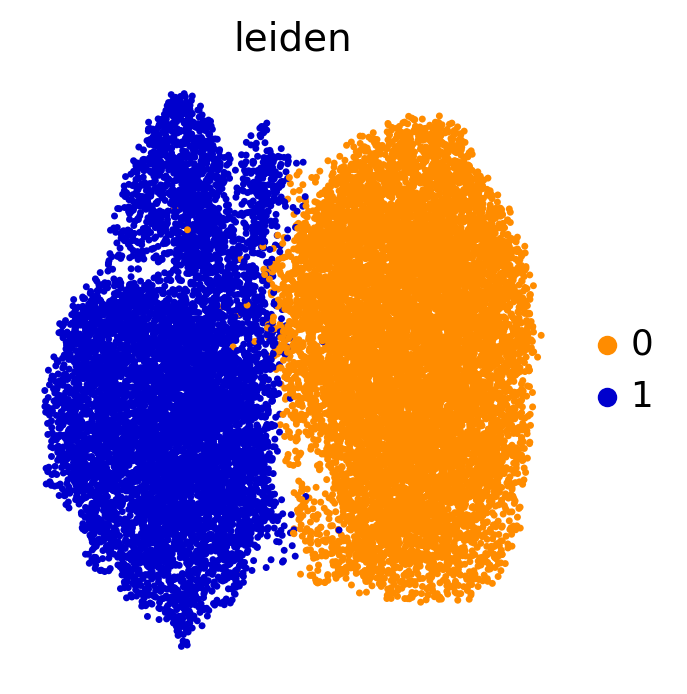

In [157]:
sc.tl.leiden(
    epi,
    resolution=0.1,
    random_state=0,
    n_iterations=2,
    directed=False,
)

sc.pl.umap(
    epi,
    color=["leiden"],s=25,palette=['darkorange','mediumblue'])

In [143]:
colors=['#8fb0ff', '#997d87', '#5a0007', '#809693', '#1b4400', '#4fc601', '#3b5dff', '#4a3b53', '#ff2f80', '#61615a','#6b7900', '#00c2a0', '#ffaa92', '#ff90c9', '#b903aa', '#d16100', '#ddefff', '#000035', '#a1c299', '#1ce6ff', '#2b0f1b','#ffff00','#ff34ff', '#ff4a46', '#008941', '#006fa6', '#a30059', '#ffdbe5', '#7a4900', '#0000a6', '#63ffac', '#b79762', '#004d43']

/opt/apps/python/3.10.2/lib/python3.10/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list


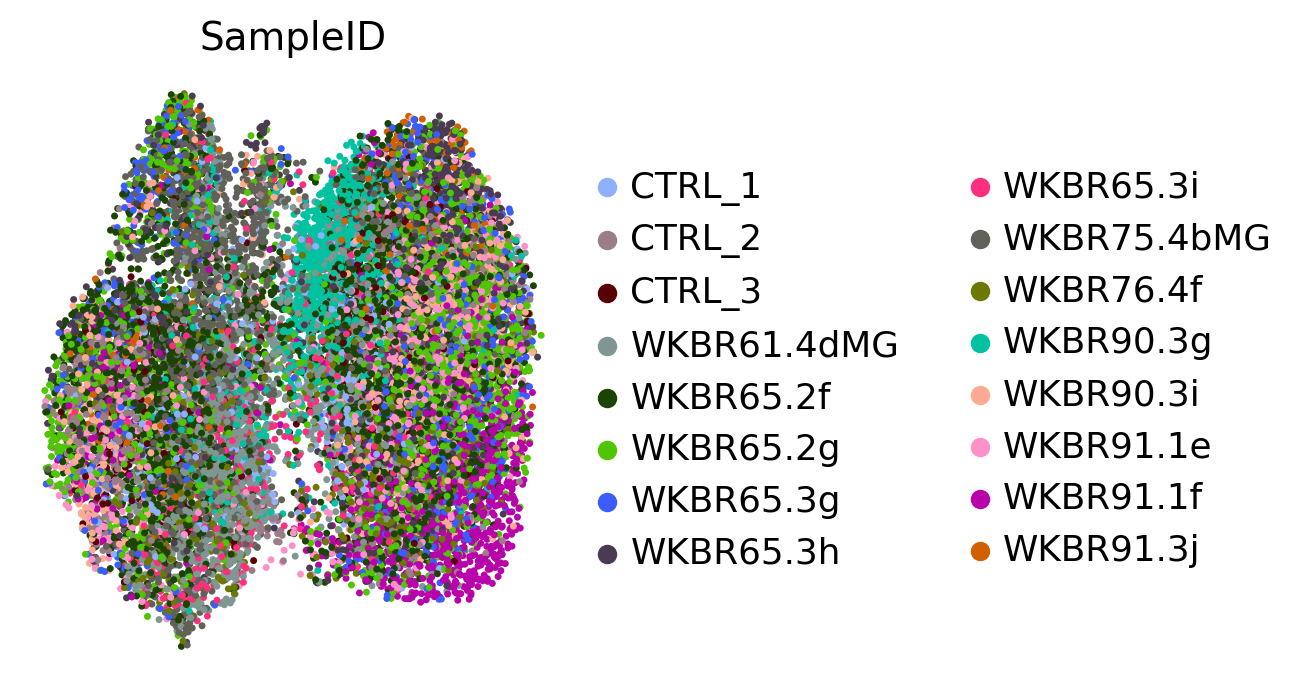

In [144]:
sc.pl.umap(epi, color='SampleID',palette=colors,
           s=25,sort_order=None,save='_wk_sampleID.pdf')

In [145]:
epi.obs=sub.obs.copy()

In [146]:
epi.obs['cell_type'] = (
    epi.obs["cell_type"]
    .map(lambda x: {"tumor": "tumor-like"}.get(x, x))
    .astype("category")
)

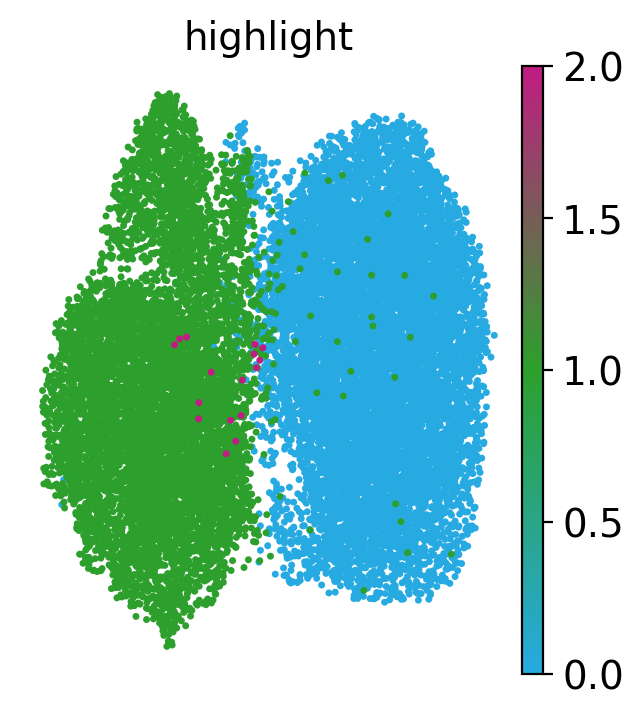

In [147]:
epi.obs['highlight'] = epi.obs['cell_type']


epi.obs['highlight'] = (
    epi.obs["highlight"]
    .map(lambda x: {"Bmyo":"0",
                    "tumor-like": "2",
                   "LumSec": "1"}.get(x, x))
    .astype('int32')
)

cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", ['#27AAE1','#2ca02c','#C11C82'])
#pl.rcParams["figure.figsize"] = (4.5,5)

sc.pl.umap(epi, color='highlight', cmap = cmap, size=25)

In [13]:
not_mutant_cnv=epi[~epi.obs['ploidy'].isin(['aneuploid'])]
not_mutant_cnv


not_mutant_cnv.obs['cnv_or_cell_type']=not_mutant_cnv.obs['cell_type']

epi.obs['cnv_or_cell_type']=not_mutant_cnv.obs['cnv_or_cell_type']

categories = np.array(
     ['Bmyo', 'LumSec', 'tumor-like', 'Aneuploid'])

epi.obs['cnv_or_cell_type'] = pd.Categorical(
   epi.obs['cnv_or_cell_type'], categories=categories, ordered=True)

epi.obs['cnv_or_cell_type'].fillna("Aneuploid", inplace=True,)

/tmp/ipykernel_2290317/3765832029.py:5: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  not_mutant_cnv.obs['cnv_or_cell_type']=not_mutant_cnv.obs['cell_type']
/tmp/ipykernel_2290317/3765832029.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  epi.obs['cnv_or_cell_type'].fillna("Aneuploid", inplace=True,)


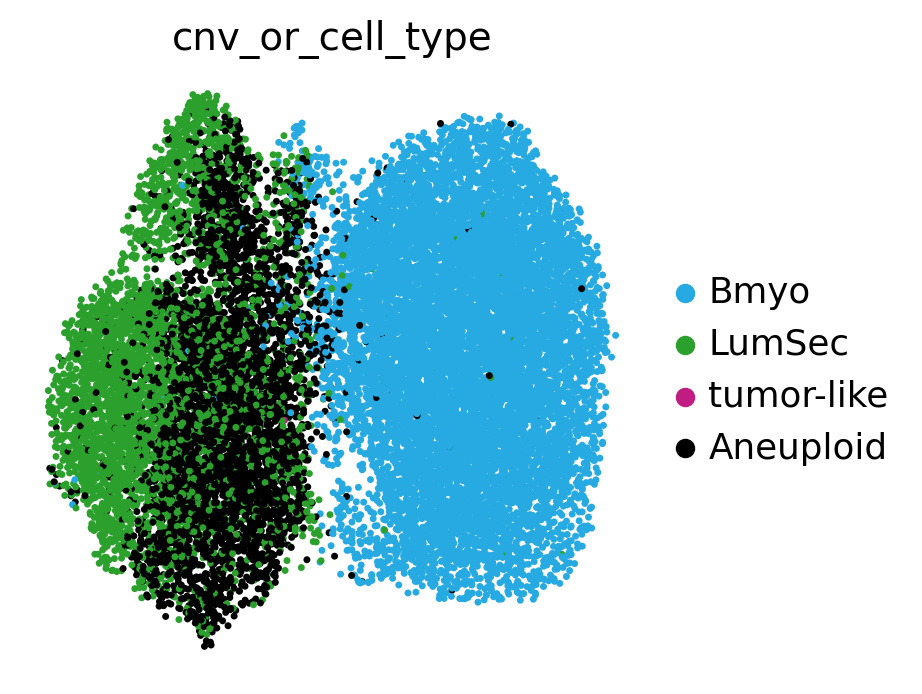

In [14]:
sc.pl.umap(epi, color='cnv_or_cell_type',size=25,
           palette=['#27AAE1','#2ca02c','#C11C82','black'])

In [148]:
epi.obs["Group"] = epi.obs["Group"].map(
    {"Control": "wildtype",
        "WKBR_MG": "mutant"
    }
)
epi.obs['condition'] = epi.obs["Group"].astype("str")
epi.obs['ploidy'] = epi.obs["ploidy"].astype("str")
epi.obs['cell_type'] = epi.obs["cell_type"].astype("str")

epi.obs['cell_type_condition'] = epi.obs['cell_type'] + ' ' + epi.obs['condition']
epi.obs['cell_type_ploidy'] = epi.obs['cell_type'] + ' ' + epi.obs['ploidy']


epi.obs['cell_type_condition'] = epi.obs["cell_type_condition"].astype("str")

epi.obs['cell_type_condition_ploidy'] = epi.obs['cell_type_condition'] + ' ' + epi.obs['ploidy']

In [19]:
epi.obs['cell_type_condition_ploidy'].value_counts()

cell_type_condition_ploidy
Bmyo mutant diploid            10286
LumSec mutant aneuploid         4314
LumSec mutant diploid           3063
LumSec wildtype diploid          818
Bmyo wildtype diploid            800
Bmyo mutant aneuploid             50
tumor-like mutant aneuploid       15
LumSec wildtype aneuploid          8
Bmyo wildtype aneuploid            4
tumor-like mutant diploid          1
Name: count, dtype: int64

In [149]:
epi.obs['cell_type_condition_ploidy'] = (
    epi.obs["cell_type_condition_ploidy"]
    .map(lambda x: {"LumSec mutant not.defined":"LumSec mutant diploid",
                   "Bmyo mutant not.defined":"Bmyo mutant diploid"}.get(x, x))
    .astype("category")
)

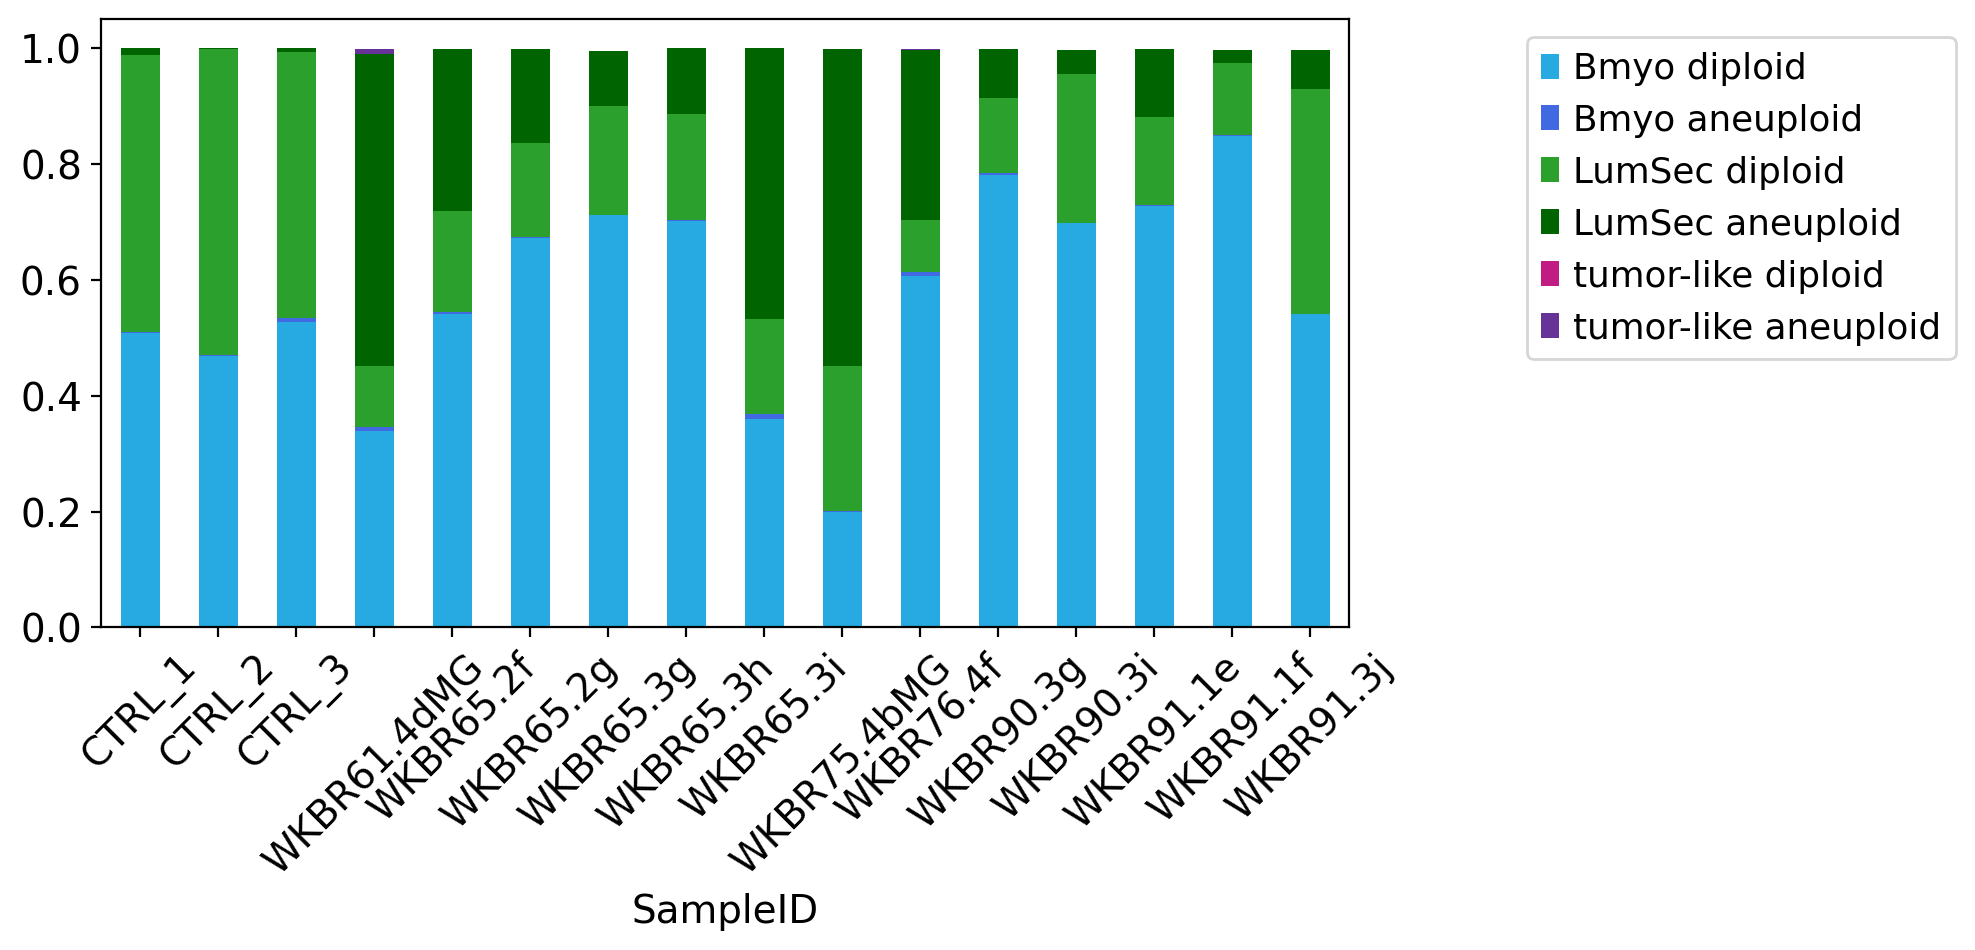

In [154]:
tmp = pd.crosstab(epi.obs['cell_type_ploidy'],epi.obs['SampleID'], 
                  normalize='columns').reindex(['Bmyo diploid','Bmyo aneuploid',
                                        'LumSec diploid','LumSec aneuploid',
                                        'tumor-like diploid','tumor-like aneuploid']).T.plot(kind='bar',
                                                                                             figsize=(8,4), 
                                                                                             stacked=True,
                                                                                             color=['#27AAE1','royalblue',
                                                               '#2ca02c','darkgreen',
                                                               '#C11C82','rebeccapurple'])
tmp.legend(title='', bbox_to_anchor=(1.5, 1),loc='upper right')
plt.grid(None)
pl.xticks(rotation=45)
pl.savefig('fig3_sample_id_cell_type_ploidy_stacked.pdf', bbox_inches='tight')

In [20]:
epi.obs['Figure_3_id'] = (
    epi.obs["cell_type_condition_ploidy"]
    .map(lambda x: {"Bmyo wildtype diploid": "Bmyo WT",
                    "Bmyo mutant diploid": "Bmyo mutant diploid",
                    "LumSec wildtype diploid": "LumSec WT",
                    "LumSec mutant diploid": "LumSec mutant diploid",
                   "tumor-like mutant aneuploid": "tumor-like mutant aneuploid",
                   "Bmyo mutant aneuploid": "Bmyo mutant aneuploid",
                    "LumSec mutant aneuploid": "LumSec mutant aneuploid",
                    "tumor mutant diploid": "tumor-like mutant diploid",
                    "tumor-like wildtype diploid": "tumor-like WT",
                    "Bmyo wildtype aneuploid": "Bmyo WT",
                   "LumSec wildtype aneuploid": "LumSec WT",
                   "tumor-like wildtype aneuploid": "tumor-like WT"}.get(x, x))
    .astype("category")
)

epi.obs['Figure_3_id'].value_counts()

Figure_3_id
Bmyo mutant diploid            10286
LumSec mutant aneuploid         4314
LumSec mutant diploid           3063
LumSec WT                        826
Bmyo WT                          804
Bmyo mutant aneuploid             50
tumor-like mutant aneuploid       15
tumor-like mutant diploid          1
Name: count, dtype: int64

/tmp/ipykernel_2290317/1315756387.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rep_match = df.groupby(['cell_type_condition','SampleID'])['Match_aneu'].mean() * 100
/tmp/ipykernel_2290317/1315756387.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='cell_type_condition', y='Match_aneu', data=rep_match, palette=colors, order=category_order)


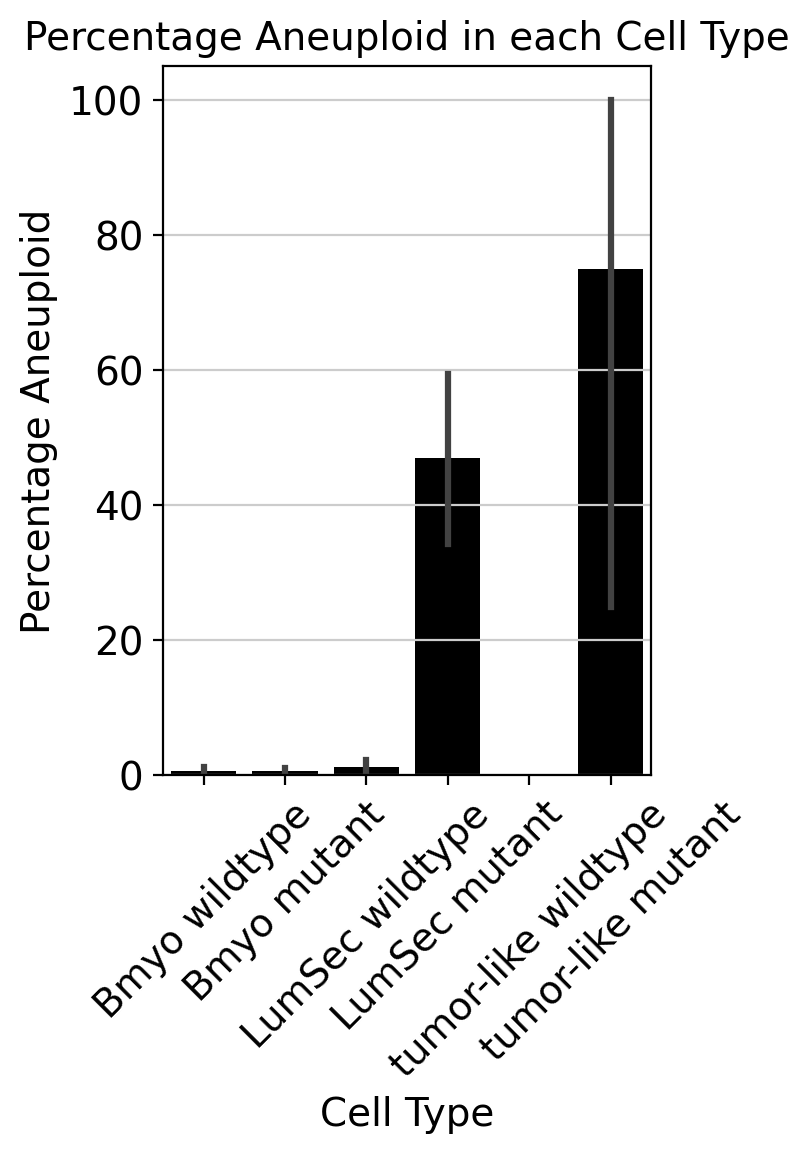

In [22]:
df=epi.obs
df['Match_aneu'] = (df['ploidy'] == "aneuploid").astype(int)
category_match = df.groupby('cell_type_condition')['Match_aneu'].mean() * 100
rep_match = df.groupby(['cell_type_condition','SampleID'])['Match_aneu'].mean() * 100
rep_match=pd.DataFrame(rep_match)

colors=['black','black','black','black','black','black']

category_order = ['Bmyo wildtype', 'Bmyo mutant',
                 'LumSec wildtype', 'LumSec mutant',
                 'tumor-like wildtype', 'tumor-like mutant']

plt.figure(figsize=(4, 6))
sns.barplot(x='cell_type_condition', y='Match_aneu', data=rep_match, palette=colors, order=category_order)
plt.xlabel('Cell Type')
#plt.ylim(0, 100)
plt.tick_params(axis='x', labelrotation=45)
plt.ylabel('Percentage Aneuploid')
plt.title('Percentage Aneuploid in each Cell Type')
plt.tight_layout()
#plt.savefig('percent_aneuploid_per_celltype_condition.pdf', format='pdf')
plt.show()

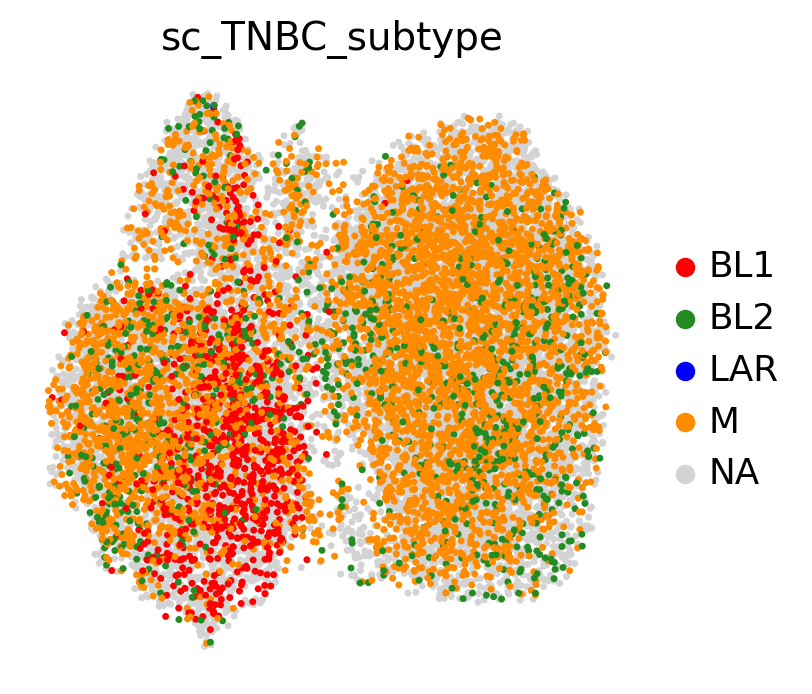

In [23]:
sc.pl.umap(epi, color='sc_TNBC_subtype', size=25,
          palette = {'BL1':'red',
                                                'BL2':'forestgreen',
                                                'LAR':'blue',
                                               'M':'darkorange',
                                               'UNS':'grey'}
          )

(array([0, 1, 2, 3, 4, 5, 6]),
 [Text(0, 0, 'Bmyo WT'),
  Text(1, 0, 'Bmyo mutant diploid'),
  Text(2, 0, 'Bmyo mutant aneuploid'),
  Text(3, 0, 'LumSec WT'),
  Text(4, 0, 'LumSec mutant diploid'),
  Text(5, 0, 'LumSec mutant aneuploid'),
  Text(6, 0, 'tumor-like mutant aneuploid')])

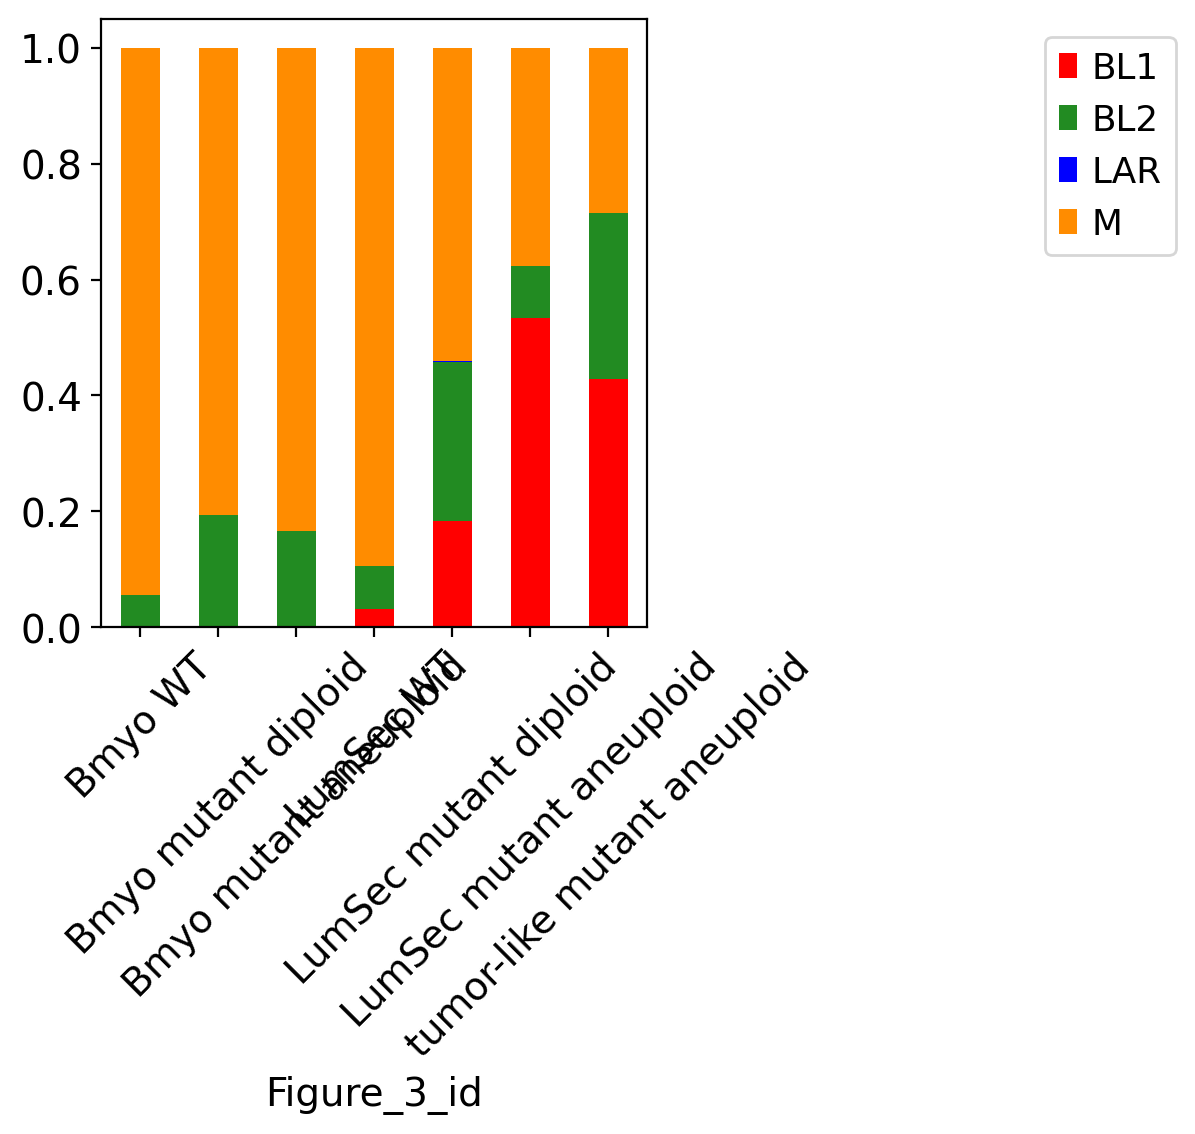

In [31]:
tmp = pd.crosstab(epi.obs['sc_TNBC_subtype'],epi.obs['Figure_3_id'], 
                  normalize='columns').reindex()[['Bmyo WT',
                  'Bmyo mutant diploid',
                  'Bmyo mutant aneuploid',
                 'LumSec WT',
                  'LumSec mutant diploid',
                  'LumSec mutant aneuploid',
                 'tumor-like mutant aneuploid']].T.plot(kind='bar',figsize=(3.5,4), stacked=True,
                                                        color=['red',
                                                'forestgreen',
                                                'blue',
                                               'darkorange',
                                               'grey'])
tmp.legend(title='', bbox_to_anchor=(2, 1),loc='upper right')
plt.grid(None)
pl.xticks(rotation=45)
#pl.savefig('fig3_subtype_cell_type_ploidy_stacked.pdf', bbox_inches='tight')